# Hybrid GMSL Forecast: Bayesian Predictive Synthesis

This notebook implements the **BPS trend constraint** for GMSL projections, combining
a non-parametric WLS trend extrapolation with the Bayesian rate-and-state DOLS model
using Bayesian Predictive Synthesis (McAlinn & West, 2019).

**Model agent options** (set `MODEL_CHOICE` in Cell 1):
- `'level'` — Instantaneous Bayesian level-space model (`fit_bayesian_level`):
  3-parameter polynomial (a·T² + b·T + c). Fast (~30 s per fit). Excellent
  approximation to the rate-and-state model for calibration and prototyping.
- `'state'` — Bayesian rate-and-state model (`fit_bayesian_state_level`):
  4-parameter model with relaxation state variable (a·T² + b·T + c + d·(S−T)).
  More physically motivated but costly (~3–5 min per fit). Recommended for
  final production runs.

**Synthesis weight options** (set `WEIGHT_MODE` in Cell 1):
- `'heuristic'` — Exponential decay w = exp(−dt/τ_eff) with fixed τ₀ and ΔT₀.
  τ_eff(ΔT) = τ₀/(1 + (ΔT/ΔT₀)²). No MCMC required.
- `'cv'` — Same exponential form, but ΔT₀ calibrated via 1D MCMC on CV data.
  τ₀ fixed from rate-and-state calibration.
- `'state'` — Same as 'cv' but τ₀ varies per posterior sample (from rate-and-state).
- `'sigmoid'` — Original 3-parameter sigmoid form (deprecated; retained for comparison).

**Physical interpretation of the exponential weight:**
- τ₀ is the baseline relaxation timescale from the rate-and-state model (~18 yr),
  calibrated on the historical record including the mid-century warming pause.
- ΔT₀ is the temperature departure at which the effective timescale halves.
- When ΔT = 0 (no new forcing beyond calibration), the trend persists for ~τ₀ years,
  capturing committed SLR from ocean thermal inertia and ice dynamics.
- As ΔT grows, the model becomes relevant more quickly because the system enters
  an uncalibrated regime where physical understanding matters more than extrapolation.

**Key design choices:**
- The synthesis weight is governed by temperature departure from the calibration domain
- Synthesis hyperparameters are calibrated via leave-future-out cross-validation
- WAIS is exempt from trend suppression (EAIS and Peninsula remain constrained)
- emcee primary sampler with dynesty cross-check
- CV refit results are cached to disk (`../data/processed/bps_cv_cache_*.npz`)
  and only regenerated when the model choice or data changes

**Notebook structure:**
1. Data loading and preparation
2. Bayesian model calibration and MC ensemble
3. WLS trend model (satellite-era non-WAIS GMSL)
4. Prior predictive checks
5. BPS cross-validation and posterior sampling
6. Per-SSP projections and combination
7. Figures and diagnostics

In [21]:
# ============================================================
# Cell 1: Imports, configuration, and model choice
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MultipleLocator
from scipy import stats, interpolate
from pathlib import Path
import warnings
import os
import sys
import hashlib
import json

# Project modules — Bayesian calibration
from bayesian_dols import (
    build_level_design_vectors,
    fit_bayesian_level,
    fit_bayesian_state_level,
    solve_state_ode,
    calibrate_exponential_prior,
    check_convergence,
    BayesianLevelResult,
    BayesianStateLevelResult,
)
from slr_data_readers import decimal_year_to_datetime, datetime_to_decimal_year

# Project modules — projections
from slr_projections import (
    project_gmsl_ensemble,
    project_gmsl_state_ensemble,
)

# Project modules — BPS trend constraint
from trend_constraint import (
    compute_T_cal_max, compute_delta_T,
    fit_wls_quadratic, predict_at_t_end, sample_derivatives,
    bma_cubic_check, trend_projection_ensemble,
    BPSSynthesis,
    compute_synthesis_weight, compute_synthesis_weight_exp,
    align_ensemble_sizes, compute_mixture_quantiles,
    generate_stochastic_transition_ensemble, add_wais_component,
    rate_smoothness_diagnostic, compute_crossover_diagnostics,
    synthesis_log_prior, synthesis_log_posterior,
    synthesis_log_prior_exp, synthesis_log_posterior_exp,
    N_ENSEMBLE, SATELLITE_START,
    DEFAULT_TAU_0, DEFAULT_DELTA_T0,
)

# ============================================================
# USER CONFIGURATION
# ============================================================

# Model choice: 'level' (fast, 3-param) or 'state' (rate-and-state, 4-param)
MODEL_CHOICE = 'level'

# Weight mode: 'heuristic', 'cv', 'state', or 'sigmoid' (deprecated)
# NOTE: 'cv' currently collapses ΔT₀ → ~0.065°C, making BPS ≈ model agent.
#   Revisit with an informative ΔT₀ prior (tighter σ_log, e.g. 0.2 instead
#   of 0.5) to see whether a meaningful trend constraint can be retained.
#   For now, 'heuristic' with ΔT₀=1.0°C provides a transparent, physically
#   motivated baseline.
WEIGHT_MODE = 'heuristic'

# Exponential weight parameters
TAU_0 = None          # loaded from bayesian_ratestate_results.json in Cell 3
DELTA_T0 = 1.0        # °C — temperature at which effective timescale halves

# Force re-run of cached CV results even if cache exists
FORCE_RERUN_CV = False

# ============================================================
# Constants
# ============================================================
M_TO_MM = 1000.0
BASELINE_YEAR = 2000.0
N_SAMPLES = 2000
FIGURE_DIR = '../figures'
CACHE_DIR = '../data/processed'

# MCMC settings (match bayesian_ratestate.ipynb)
MCMC_N_SAMPLES = 5000
MCMC_N_WALKERS_LEVEL = 32
MCMC_N_WALKERS_STATE = 64
MCMC_N_BURNIN_LEVEL = 1000
MCMC_N_BURNIN_STATE = 3000

# Prior configuration (all in meters; matching bayesian_ratestate.ipynb)
PRIOR_SCALE_A = calibrate_exponential_prior(prob_exceed=0.10, threshold=0.005)
PRIOR_SCALE_B = 0.010
PRIOR_C_MEAN = 0.002
PRIOR_C_SIGMA = 0.005
PRIOR_SCALE_D = calibrate_exponential_prior(prob_exceed=0.10, threshold=0.003)
PRIOR_LOG_TAU_MEAN = np.log(20)
PRIOR_LOG_TAU_SIGMA = 0.7
PRIOR_SIGMA_EXTRA_SCALE = 0.005
PRIOR_H0_SIGMA = 0.050

'''
# Matplotlib configuration
plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'legend.fontsize': 9,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
})
'''
plt.style.use('seaborn-v0_8-poster')

warnings.filterwarnings('ignore', category=FutureWarning)
print(f'Model choice:  {MODEL_CHOICE}')
print(f'Weight mode:   {WEIGHT_MODE}')
print(f'  ΔT₀ (init):   {DELTA_T0:.2f} °C')
print(f'  a ~ Exp(mean={PRIOR_SCALE_A*M_TO_MM:.2f} mm/yr/°C²)')
print(f'  b ~ HalfNormal(σ={PRIOR_SCALE_B*M_TO_MM:.1f} mm/yr/°C)')
print(f'  c ~ Normal({PRIOR_C_MEAN*M_TO_MM:.1f}, {PRIOR_C_SIGMA*M_TO_MM:.1f} mm/yr)')
if MODEL_CHOICE == 'state':
    print(f'  d ~ Exp(mean={PRIOR_SCALE_D*M_TO_MM:.2f} mm/yr/°C)')
    print(f'  τ ~ LogNormal(median=20 yr)')
print('Imports complete.')

Model choice:  level
Weight mode:   heuristic
  ΔT₀ (init):   1.00 °C
  a ~ Exp(mean=2.17 mm/yr/°C²)
  b ~ HalfNormal(σ=10.0 mm/yr/°C)
  c ~ Normal(2.0, 5.0 mm/yr)
Imports complete.


## 1. Data Loading

Load harmonized observations and IPCC temperature projections from the HDF5 store.
All sea-level data in **meters**, temperature in **degrees C**, baseline 1995-2005.

In [22]:
# ============================================================
# Cell 2: Load data from HDF5 + τ₀ from rate-and-state results
# ============================================================
h5_path = '../data/processed/slr_processed_data.h5'

with pd.HDFStore(h5_path, 'r') as store:
    # Configuration
    config = store['/config']
    baseline_start = int(config['baseline_start'].iloc[0])
    baseline_end = int(config['baseline_end'].iloc[0])

    # Harmonized observations (baseline = 1995-2005)
    df_frederikse = store['/harmonized/df_frederikse_h']
    df_berkeley = store['/harmonized/df_berkeley_h']
    df_imbie_wais = store['/harmonized/df_imbie_wais_h']

    # Temperature projections (IPCC AR6)
    temp_hist = store['/projections/temp/Historical']
    temp_projections = {}
    ssp_keys = {
        'SSP1-1.9': 'SSP1_1_9', 'SSP1-2.6': 'SSP1_2_6',
        'SSP2-4.5': 'SSP2_4_5', 'SSP3-7.0': 'SSP3_7_0',
        'SSP5-8.5': 'SSP5_8_5',
    }
    for name, key in ssp_keys.items():
        temp_projections[name] = store[f'/projections/temp/{key}']

    # IPCC GMSL projections (medium confidence)
    ipcc_gmsl = {}
    ssp_gmsl_keys = {
        'SSP1-1.9': 'ssp119', 'SSP1-2.6': 'ssp126',
        'SSP2-4.5': 'ssp245', 'SSP3-7.0': 'ssp370',
        'SSP5-8.5': 'ssp585',
    }
    for name, key in ssp_gmsl_keys.items():
        if f'/projections/gmsl/{key}' in store:
            ipcc_gmsl[name] = store[f'/projections/gmsl/{key}']

    # Kinematics
    kinematics_fred = store['/kinematics/gmsl/frederikse']

print(f'Frederikse GMSL: {df_frederikse.index[0].year}--{df_frederikse.index[-1].year}')
print(f'Berkeley temp:   {df_berkeley.index[0].year}--{df_berkeley.index[-1].year}')
print(f'IMBIE WAIS:      {df_imbie_wais.index[0].year}--{df_imbie_wais.index[-1].year}')
print(f'SSP scenarios:   {list(temp_projections.keys())}')
print(f'Baseline:        {baseline_start}--{baseline_end}')

# --- Load τ₀ from rate-and-state Bayesian calibration ---
ratestate_json = '../data/processed/bayesian_ratestate_results.json'
if os.path.exists(ratestate_json):
    with open(ratestate_json) as f:
        ratestate_results = json.load(f)
    tau_from_json = ratestate_results['calibration']['tau_yr']['median']
    tau_hdi = ratestate_results['calibration']['tau_yr']['hdi_94']
    if TAU_0 is None:
        TAU_0 = tau_from_json
    print(f'\nRate-and-state τ₀ = {tau_from_json:.1f} yr '
          f'(94% HDI: [{tau_hdi[0]:.1f}, {tau_hdi[1]:.1f}] yr)')
    print(f'Using TAU_0 = {TAU_0:.1f} yr')
else:
    if TAU_0 is None:
        TAU_0 = DEFAULT_TAU_0
    print(f'\nRate-and-state results not found; using default TAU_0 = {TAU_0:.1f} yr')

Frederikse GMSL: 1900--2018
Berkeley temp:   1850--2024
IMBIE WAIS:      1992--2020
SSP scenarios:   ['SSP1-1.9', 'SSP1-2.6', 'SSP2-4.5', 'SSP3-7.0', 'SSP5-8.5']
Baseline:        1995--2005

Rate-and-state τ₀ = 18.7 yr (94% HDI: [4.4, 81.2] yr)
Using TAU_0 = 18.7 yr


In [23]:
# ============================================================
# Cell 3: Prepare time series for Bayesian calibration and BPS
# ============================================================

# --- Extract GMSL observations (annual, meters) ---
H_obs_full = df_frederikse['gmsl'].values              # meters
sigma_gmsl = df_frederikse['gmsl_sigma'].values         # meters
tws_sigma = df_frederikse['tws_sigma'].values           # meters
obs_years = np.array([
    t.year + (t.month - 0.5) / 12 for t in df_frederikse.index
])

# t_end: last year of observational data
t_end = obs_years[-1]

# --- Observation uncertainty with dam impoundment correction ---
# (matching bayesian_ratestate.ipynb exactly)
DAM_PEAK = 1970.0
DAM_WIDTH = 25.0
DAM_AMPLITUDE = 0.003  # 3 mm in meters
dam_extra = DAM_AMPLITUDE * np.exp(
    -0.5 * ((obs_years - DAM_PEAK) / DAM_WIDTH)**2
)
sigma_tws_total = np.sqrt(tws_sigma**2 + dam_extra**2)
sigma_obs_fixed = np.sqrt(sigma_gmsl**2 + sigma_tws_total**2)

print(f'Frederikse GMSL: {len(H_obs_full)} annual obs, '
      f'{obs_years[0]:.1f}\u2013{obs_years[-1]:.1f}')
print(f'sigma_obs range: {sigma_obs_fixed.min()*M_TO_MM:.1f} to '
      f'{sigma_obs_fixed.max()*M_TO_MM:.1f} mm')

# --- Monthly temperature (needed for design vectors and ODE spin-up) ---
T_monthly_all = df_berkeley['temperature'].values
time_monthly_all = np.array([
    t.year + (t.month - 0.5) / 12 for t in df_berkeley.index
])

# Restrict to observation period for calibration
mask_berk = ((time_monthly_all >= obs_years[0]) &
             (time_monthly_all <= obs_years[-1]))
T_monthly_fit = T_monthly_all[mask_berk]
time_monthly_fit = time_monthly_all[mask_berk]

print(f'Berkeley Earth T: {len(T_monthly_fit)} monthly obs, '
      f'{time_monthly_fit[0]:.1f}\u2013{time_monthly_fit[-1]:.1f}')
print(f'Full T record: {len(T_monthly_all)} months, '
      f'{time_monthly_all[0]:.1f}\u2013{time_monthly_all[-1]:.1f}')

# --- Build design vectors for level-space Bayesian models ---
dv = build_level_design_vectors(
    temperature_monthly=T_monthly_fit,
    time_monthly=time_monthly_fit,
    obs_times=obs_years,
)
I2_obs = dv['I2_obs']
I1_obs = dv['I1_obs']
I0_obs = dv['I0_obs']
obs_idx = dv['obs_idx']

print(f'Design vectors: {len(I2_obs)} obs points from '
      f'{len(T_monthly_fit)} monthly grid')

# --- Annual-mean temperature (for T_cal_max and satellite-era analysis) ---
# IMPORTANT: Must use calendar-year means, NOT point interpolation at mid-year.
# np.interp at July would give just the July value, not the annual mean,
# which leads to T_cal_max being too low and ΔT being computed incorrectly.
df_berk_annual = df_berkeley.resample('YE').mean().dropna(subset=['temperature'])
berk_annual_years = np.array([t.year + 0.5 for t in df_berk_annual.index])
berk_annual_T = df_berk_annual['temperature'].values
T_obs_annual = np.interp(obs_years, berk_annual_years, berk_annual_T)

print(f'T_obs_annual range: [{T_obs_annual.min():.3f}, {T_obs_annual.max():.3f}] C')
print(f'T_cal_max (full record): {T_obs_annual.max():.3f} C '
      f'(year {obs_years[np.argmax(T_obs_annual)]:.0f})')

# Satellite-era mask
sat_mask = obs_years >= SATELLITE_START
years_sat = obs_years[sat_mask]
gmsl_sat = H_obs_full[sat_mask]
T_obs_sat = T_obs_annual[sat_mask]

# --- WAIS contribution (annual, meters, for satellite era) ---
df_wais_annual = df_imbie_wais.resample('YE').mean().dropna()
wais_time = np.array([datetime_to_decimal_year(t) for t in df_wais_annual.index])
wais_sl = df_wais_annual['cumulative_mass_balance'].values

print(f'WAIS record:    {wais_time[0]:.0f}--{wais_time[-1]:.0f} ({len(wais_time)} years)')

# --- Non-WAIS GMSL for satellite era ---
wais_on_full = np.interp(obs_years, wais_time, wais_sl, left=0.0, right=np.nan)
gmsl_non_wais_sat = gmsl_sat - wais_on_full[sat_mask]

# Uncertainty for satellite era
sigma_sat = sigma_obs_fixed[sat_mask]

print(f'Satellite-era non-WAIS GMSL: {years_sat[0]:.0f}--{years_sat[-1]:.0f} '
      f'({len(years_sat)} pts)')

# --- Build continuous SSP temperature scenarios ---
# CRITICAL: Rebaseline SSP temperatures from pre-industrial (~1850-1900)
# to the Berkeley Earth 1995-2005 baseline used for model calibration.
# Without this, rate = a*T² + b*T + c is evaluated at ~0.75°C too high,
# producing vastly inflated projections (quadratic amplification).
full_temp_scenarios = {}
for ssp_name, temp_df in temp_projections.items():
    T_proj = temp_df['temperature'].values.copy()
    if 'decimal_year' in temp_df.columns:
        t_proj = temp_df['decimal_year'].values
    else:
        t_proj = np.array([datetime_to_decimal_year(t) for t in temp_df.index])
    # Match IPCC and Berkeley Earth at the overlap year
    ipcc_first_year = t_proj[0]
    idx_overlap = np.argmin(np.abs(berk_annual_years - ipcc_first_year))
    berk_at_overlap = berk_annual_T[idx_overlap]
    ipcc_at_overlap = T_proj[0]
    temp_baseline_offset = ipcc_at_overlap - berk_at_overlap
    T_proj -= temp_baseline_offset
    full_temp_scenarios[ssp_name] = pd.DataFrame({
        'temperature': T_proj,
        'decimal_year': t_proj,
    })

print(f'SSP temperature scenarios prepared: {list(full_temp_scenarios.keys())}')
print(f'Temperature baseline offset (pre-industrial \u2192 Berkeley Earth): '
      f'{temp_baseline_offset:.3f} \u00b0C')
# Verify: SSP T at overlap should match Berkeley T
_check_ssp = 'SSP2-4.5'
_t0 = full_temp_scenarios[_check_ssp]['decimal_year'].iloc[0]
_T0 = full_temp_scenarios[_check_ssp]['temperature'].iloc[0]
_Tb = np.interp(_t0, berk_annual_years, berk_annual_T)
print(f'Verification at {_t0:.0f}: SSP T = {_T0:.3f} \u00b0C, '
      f'Berkeley T = {_Tb:.3f} \u00b0C (diff = {_T0 - _Tb:.4f} \u00b0C)')

Frederikse GMSL: 119 annual obs, 1900.5–2018.5
sigma_obs range: 4.4 to 20.6 mm
Berkeley Earth T: 1417 monthly obs, 1900.5–2018.5
Full T record: 2100 months, 1850.0–2025.0
Design vectors: 119 obs points from 1417 monthly grid
T_obs_annual range: [-1.085, 0.488] C
T_cal_max (full record): 0.488 C (year 2017)
WAIS record:    1993--2021 (29 years)
Satellite-era non-WAIS GMSL: 1994--2019 (26 pts)
SSP temperature scenarios prepared: ['SSP1-1.9', 'SSP1-2.6', 'SSP2-4.5', 'SSP3-7.0', 'SSP5-8.5']
Temperature baseline offset (pre-industrial → Berkeley Earth): 0.898 °C
Verification at 2015: SSP T = 0.213 °C, Berkeley T = 0.285 °C (diff = -0.0722 °C)


## 2. Bayesian Model Calibration and MC Ensemble

Calibrate either the instantaneous (`fit_bayesian_level`) or rate-and-state
(`fit_bayesian_state_level`) model on the full observational record, then generate
Monte Carlo projection ensembles for each SSP using the posterior samples directly.
These serve as the **model agent** in the BPS synthesis.

In [24]:
# ============================================================
# Cell 4: Bayesian calibration on full record
# ============================================================

if MODEL_CHOICE == 'level':
    # --- Instantaneous level-space model (3-param: a, b, c) ---
    print('Fitting instantaneous Bayesian level-space model...')
    bayes_result = fit_bayesian_level(
        H_obs=H_obs_full,
        sigma_obs=sigma_obs_fixed,
        I2_obs=I2_obs,
        I1_obs=I1_obs,
        I0_obs=I0_obs,
        prior_scale_a=PRIOR_SCALE_A,
        prior_scale_b=PRIOR_SCALE_B,
        prior_c_mean=PRIOR_C_MEAN,
        prior_c_sigma=PRIOR_C_SIGMA,
        prior_sigma_extra_scale=PRIOR_SIGMA_EXTRA_SCALE,
        prior_H0_sigma=PRIOR_H0_SIGMA,
        n_samples=MCMC_N_SAMPLES,
        n_walkers=MCMC_N_WALKERS_LEVEL,
        n_burnin=MCMC_N_BURNIN_LEVEL,
        progress=True,
        seed=42,
    )
    # Extract posterior samples: (n_posterior, 3) — [a, b, c]
    posterior_samples_abc = bayes_result.posterior_samples
    coeffs_mean = bayes_result.physical_coefficients  # [a, b, c]
    coeffs_cov = bayes_result.physical_covariance     # (3, 3)

    print(f'\nBayesian level-space calibration:')
    print(f'  da/dT   = {coeffs_mean[0]*M_TO_MM:.4f} mm/yr/C^2')
    print(f'  alpha_0 = {coeffs_mean[1]*M_TO_MM:.4f} mm/yr/C')
    print(f'  trend   = {coeffs_mean[2]*M_TO_MM:.4f} mm/yr')
    print(f'  R^2     = {bayes_result.r2:.4f}')
    print(f'  sigma_extra = {np.median(bayes_result.sigma_extra_posterior)*M_TO_MM:.2f} mm (median)')
    print(f'  n_posterior = {posterior_samples_abc.shape[0]}')

elif MODEL_CHOICE == 'state':
    # --- Rate-and-state model (4-param: a, b, c, d + tau) ---
    # First fit instantaneous model for initialization
    print('Fitting instantaneous model for initialization...')
    init_result = fit_bayesian_level(
        H_obs=H_obs_full,
        sigma_obs=sigma_obs_fixed,
        I2_obs=I2_obs,
        I1_obs=I1_obs,
        I0_obs=I0_obs,
        prior_scale_a=PRIOR_SCALE_A,
        prior_scale_b=PRIOR_SCALE_B,
        prior_c_mean=PRIOR_C_MEAN,
        prior_c_sigma=PRIOR_C_SIGMA,
        prior_sigma_extra_scale=PRIOR_SIGMA_EXTRA_SCALE,
        prior_H0_sigma=PRIOR_H0_SIGMA,
        n_samples=MCMC_N_SAMPLES,
        n_walkers=MCMC_N_WALKERS_LEVEL,
        n_burnin=MCMC_N_BURNIN_LEVEL,
        progress=True,
        seed=42,
    )

    print('\nFitting rate-and-state Bayesian model...')
    bayes_result = fit_bayesian_state_level(
        H_obs=H_obs_full,
        sigma_obs=sigma_obs_fixed,
        I2_obs=I2_obs,
        I1_obs=I1_obs,
        I0_obs=I0_obs,
        T_monthly=T_monthly_fit,
        time_monthly=time_monthly_fit,
        obs_idx=obs_idx,
        prior_scale_a=PRIOR_SCALE_A,
        prior_scale_b=PRIOR_SCALE_B,
        prior_c_mean=PRIOR_C_MEAN,
        prior_c_sigma=PRIOR_C_SIGMA,
        prior_scale_d=PRIOR_SCALE_D,
        prior_log_tau_mean=PRIOR_LOG_TAU_MEAN,
        prior_log_tau_sigma=PRIOR_LOG_TAU_SIGMA,
        prior_sigma_extra_scale=PRIOR_SIGMA_EXTRA_SCALE,
        prior_H0_sigma=PRIOR_H0_SIGMA,
        n_samples=MCMC_N_SAMPLES,
        n_walkers=MCMC_N_WALKERS_STATE,
        n_burnin=MCMC_N_BURNIN_STATE,
        progress=True,
        seed=42,
        init_from_level=init_result,
        init_order=1,
    )
    # Extract posterior samples: (n_posterior, 4) — [a, b, c, d]
    posterior_samples_abcd = bayes_result.posterior_samples
    # For compatibility, also extract the [a, b, c] subset
    posterior_samples_abc = posterior_samples_abcd[:, :3]
    coeffs_mean = bayes_result.physical_coefficients  # [a, b, c, d]
    coeffs_cov = bayes_result.physical_covariance     # (4, 4)

    print(f'\nBayesian rate-and-state calibration:')
    print(f'  da/dT   = {coeffs_mean[0]*M_TO_MM:.4f} mm/yr/C^2')
    print(f'  alpha_0 = {coeffs_mean[1]*M_TO_MM:.4f} mm/yr/C')
    print(f'  trend   = {coeffs_mean[2]*M_TO_MM:.4f} mm/yr')
    print(f'  d_diseq = {coeffs_mean[3]*M_TO_MM:.4f} mm/yr/C')
    tau_med = np.median(bayes_result.tau_posterior)
    tau_p5 = np.percentile(bayes_result.tau_posterior, 5)
    tau_p95 = np.percentile(bayes_result.tau_posterior, 95)
    print(f'  tau     = {tau_med:.1f} yr (90% CI: {tau_p5:.1f}--{tau_p95:.1f})')
    print(f'  R^2     = {bayes_result.r2:.4f}')
    print(f'  sigma_extra = {np.median(bayes_result.sigma_extra_posterior)*M_TO_MM:.2f} mm (median)')
    print(f'  n_posterior = {posterior_samples_abcd.shape[0]}')

else:
    raise ValueError(f"MODEL_CHOICE must be 'level' or 'state', got '{MODEL_CHOICE}'")

Fitting instantaneous Bayesian level-space model...
Bayesian level-space fit: n=119 observations, ndim=5
  Priors: a~Exp(mean=2.17 mm/yr/°C²), b~HN(10.0 mm/yr/°C), c~N(2.0, 5.0 mm/yr), σ_extra~HC(5.0 mm)
  OLS init: a=3.024, b=3.754, c=2.428 mm/yr, σ_extra=9.33 mm


100%|████████████████████████████████████████████████████████████████| 6000/6000 [00:08<00:00, 700.90it/s]


  Convergence diagnostics:
    dalpha_dT: R-hat=1.012  ESS_bulk=332  ESS_tail=875
    alpha0: R-hat=1.015  ESS_bulk=330  ESS_tail=1006
    trend: R-hat=1.027  ESS_bulk=263  ESS_tail=871
    log_sigma_extra: R-hat=1.006  ESS_bulk=320  ESS_tail=539
    H0: R-hat=1.010  ESS_bulk=321  ESS_tail=719
  All diagnostics OK (R-hat < 1.05, ESS > 100)
  Posterior mean: a=4.631, b=5.002, c=2.484 mm/yr
  σ_extra: median=1.23 mm [0.08, 3.51]
  R² = 0.9695,  acceptance = 0.54

Bayesian level-space calibration:
  da/dT   = 4.6311 mm/yr/C^2
  alpha_0 = 5.0021 mm/yr/C
  trend   = 2.4842 mm/yr
  R^2     = 0.9695
  sigma_extra = 1.23 mm (median)
  n_posterior = 160000


In [25]:
# ============================================================
# Cell 5: Run MC ensemble projections (model agent) using posterior samples
# ============================================================
# The project_gmsl_* functions return summary DataFrames.
# For BPS we need per-sample trajectories, so we generate them directly
# from the posterior samples (preserving non-Gaussianity).

def run_bayesian_ensemble(posterior_samp, temp_scenarios, baseline_year=2005.0,
                          n_samples=2000, seed=42, tau_samples=None,
                          T_monthly_hist=None, time_monthly_hist=None):
    """Generate per-sample GMSL trajectories from Bayesian posterior samples.

    Uses posterior_samp directly (no Gaussian approximation).
    For MODEL_CHOICE='state', also integrates the state ODE per sample.
    """
    rng = np.random.RandomState(seed)
    n_post = posterior_samp.shape[0]
    # Draw indices from posterior (with replacement if n_samples > n_post)
    idx = rng.choice(n_post, n_samples, replace=(n_samples > n_post))
    coeff_draws = posterior_samp[idx]

    if tau_samples is not None:
        tau_draws = tau_samples[idx]

    results = {}
    for sname, temp_df in temp_scenarios.items():
        T = temp_df['temperature'].values
        time_years = temp_df['decimal_year'].values
        dt = np.diff(time_years)
        baseline_idx = np.argmin(np.abs(time_years - baseline_year))
        nt = len(T)

        gmsl_samples = np.zeros((n_samples, nt))
        rate_samples = np.zeros((n_samples, nt))

        for k in range(n_samples):
            if posterior_samp.shape[1] == 3:
                # Level model: rate = a*T^2 + b*T + c
                a, b, c = coeff_draws[k]
                rate = a * T**2 + b * T + c
            else:
                # State model: rate = a*T^2 + b*T + c + d*(S - T)
                a, b, c, d = coeff_draws[k]
                tau_k = tau_draws[k]

                # Build full temperature series: historical + projection
                proj_start = time_years[0]
                hist_mask = time_monthly_hist < proj_start
                T_full = np.concatenate([T_monthly_hist[hist_mask], T])
                t_full = np.concatenate([time_monthly_hist[hist_mask], time_years])

                # Solve state ODE on the full series
                S_full = solve_state_ode(T_full, t_full, tau_k)

                # Extract projection portion
                n_hist = hist_mask.sum()
                S_proj = S_full[n_hist:]
                rate = a * T**2 + b * T + c + d * (S_proj - T)

            rate_samples[k] = rate

            # Integrate rate -> GMSL (trapezoidal, from baseline)
            gmsl = np.zeros(nt)
            for i in range(baseline_idx, nt - 1):
                gmsl[i + 1] = gmsl[i] + 0.5 * (rate[i] + rate[i + 1]) * dt[i]
            for i in range(baseline_idx, 0, -1):
                gmsl[i - 1] = gmsl[i] - 0.5 * (rate[i] + rate[i - 1]) * dt[i - 1]
            gmsl_samples[k] = gmsl

        results[sname] = {
            'time': time_years,
            'gmsl_samples': gmsl_samples,
            'rate_samples': rate_samples,
            'gmsl_median': np.median(gmsl_samples, axis=0),
            'gmsl_p5': np.percentile(gmsl_samples, 5, axis=0),
            'gmsl_p95': np.percentile(gmsl_samples, 95, axis=0),
            'gmsl_p17': np.percentile(gmsl_samples, 17, axis=0),
            'gmsl_p83': np.percentile(gmsl_samples, 83, axis=0),
        }
    return results


if MODEL_CHOICE == 'level':
    mc_results = run_bayesian_ensemble(
        bayes_result.posterior_samples,
        full_temp_scenarios,
        baseline_year=BASELINE_YEAR,
        n_samples=N_SAMPLES,
        seed=42,
    )
elif MODEL_CHOICE == 'state':
    mc_results = run_bayesian_ensemble(
        bayes_result.posterior_samples,
        full_temp_scenarios,
        baseline_year=BASELINE_YEAR,
        n_samples=N_SAMPLES,
        seed=42,
        tau_samples=bayes_result.tau_posterior,
        T_monthly_hist=T_monthly_all,
        time_monthly_hist=time_monthly_all,
    )

print(f'MC ensemble complete (MODEL_CHOICE={MODEL_CHOICE}):')
for ssp, mc in mc_results.items():
    val_2100 = np.interp(2100, mc['time'], mc['gmsl_median']) * M_TO_MM
    print(f'  {ssp}: median GMSL at 2100 = {val_2100:.0f} mm')

MC ensemble complete (MODEL_CHOICE=level):
  SSP1-1.9: median GMSL at 2100 = 580 mm
  SSP1-2.6: median GMSL at 2100 = 766 mm
  SSP2-4.5: median GMSL at 2100 = 1293 mm
  SSP3-7.0: median GMSL at 2100 = 1988 mm
  SSP5-8.5: median GMSL at 2100 = 2764 mm


## 3. WLS Trend Model (Trend Agent)

Fit a WLS quadratic to satellite-era **non-WAIS** GMSL, extract (H, r, r-dot) at t_end
with GIA and WAIS-subtraction systematic inflations, and check for cubic significance via BMA.

In [26]:
# ============================================================
# Cell 6: Fit WLS quadratic and extract derivatives at t_end
# ============================================================

# Fit WLS quadratic to satellite-era non-WAIS GMSL
wls_fit = fit_wls_quadratic(
    years_sat, gmsl_non_wais_sat, sigma_sat,
    satellite_start=SATELLITE_START, fix_scale=True,
)

# Predict at t_end with systematic inflations
# sigma_gia = 0.15 mm/yr = 0.15e-3 m/yr
# sigma_ais_sys = 0.10 mm/yr = 0.10e-3 m/yr
prediction = predict_at_t_end(
    wls_fit, t_end,
    sigma_gia=0.15e-3, sigma_ais_sys=0.10e-3,
)

print(f'WLS quadratic fit ({SATELLITE_START:.0f}--{t_end:.0f}):')
print(f'  t_ref     = {wls_fit["t_ref"]:.1f}')
print(f'  sigma_sq  = {wls_fit["sigma_sq_est"]:.3f} (diagnostic; 1.0 = trusted)')
print(f'  n_obs     = {wls_fit["n_obs"]}')
print()
print(f'At t_end = {t_end:.0f}:')
print(f'  H    = {prediction["H_mean"]*M_TO_MM:.1f} mm')
print(f'  r    = {prediction["r_mean"]*M_TO_MM:.2f} mm/yr')
print(f'  rdot = {prediction["rdot_mean"]*M_TO_MM:.4f} mm/yr^2')
print()
print('Covariance (H, r, rdot) [m, m/yr, m/yr^2]:')
cov_3 = prediction['cov_3x3']
for i in range(3):
    row = '  '.join(f'{cov_3[i, j]:.2e}' for j in range(3))
    print(f'  [{row}]')

# BMA cubic check
cubic_check = bma_cubic_check(
    years_sat, gmsl_non_wais_sat, sigma_sat, t_end,
    satellite_start=SATELLITE_START,
)
print(f'\nBMA cubic check:')
print(f'  P(quadratic) = {cubic_check["bma_prob_quadratic"]:.3f}')
print(f'  P(cubic)     = {cubic_check["bma_prob_cubic"]:.3f}')
print(f'  Cubic coeff  = {cubic_check["cubic_coeff"]:.2e} +/- {cubic_check["cubic_coeff_se"]:.2e}')
if cubic_check['scale_diagnostic_flag']:
    print(f'  WARNING: sigma_sq = {cubic_check["sigma_sq_estimated"]:.2f} > 2.0')

WLS quadratic fit (1993--2019):
  t_ref     = 2006.0
  sigma_sq  = 1.115 (diagnostic; 1.0 = trusted)
  n_obs     = 26

At t_end = 2019:
  H    = 56.7 mm
  r    = 3.88 mm/yr
  rdot = 0.0662 mm/yr^2

Covariance (H, r, rdot) [m, m/yr, m/yr^2]:
  [1.52e-05  2.04e-06  1.10e-07]
  [2.04e-06  3.75e-07  2.61e-08]
  [1.10e-07  2.61e-08  2.16e-09]

BMA cubic check:
  P(quadratic) = 0.026
  P(cubic)     = 0.974
  Cubic coeff  = 1.04e-05 +/- 3.13e-06


## 4. Prior Predictive Checks

Verify the priors on (phi_0, kappa_net, kappa_t) produce physically reasonable weights
before running the full pipeline.

In [27]:
# ============================================================
# Cell 7: Prior predictive checks on synthesis weights
# ============================================================
T_max_cal = compute_T_cal_max(T_obs_annual)
print(f'T_cal_max = {T_max_cal:.3f} °C (relative to {baseline_start}-{baseline_end} baseline)')
print(f'Weight mode: {WEIGHT_MODE}')
print(f'τ₀ = {TAU_0:.1f} yr, ΔT₀ = {DELTA_T0:.2f} °C')

rng = np.random.default_rng(42)
n_prior = 5000

if WEIGHT_MODE in ('heuristic', 'cv', 'state'):
    # --- Exponential weight prior predictive ---
    # ΔT₀ ~ LogNormal(log(1.0), 0.5)
    dT0_prior = rng.lognormal(mean=0.0, sigma=0.5, size=n_prior)
    print(f'ΔT₀ prior: LogNormal(median=1.0°C, σ_log=0.5)')
    print(f'  90% CI: [{np.percentile(dT0_prior, 5):.2f}, {np.percentile(dT0_prior, 95):.2f}] °C')

    check_cases = [
        ('5yr, all SSPs (ΔT~0)',       5.0,  0.0,   'w > 0.7'),
        ('10yr, SSP2-4.5 (ΔT~0.15)',  10.0, 0.15,  'w in [0.4, 0.8]'),
        ('20yr, SSP2-4.5 (ΔT~0.5)',   20.0, 0.5,   'w in [0.1, 0.5]'),
        ('20yr, SSP1-2.6 (ΔT~0)',     20.0, 0.0,   'w in [0.2, 0.6]'),
        ('10yr, SSP5-8.5 (ΔT~0.3)',   10.0, 0.3,   'w in [0.3, 0.8]'),
        ('40yr, SSP2-4.5 (ΔT~1.0)',   40.0, 1.0,   'w < 0.1'),
        ('80yr, all SSPs (ΔT~0)',      80.0, 0.0,   'w < 0.05'),
    ]

    print(f'\n{"Case":<35s}  {"Median w":>10s}  {"P10":>6s}  {"P90":>6s}  Target')
    print('-' * 90)

    for label, dt_val, dT_val, target in check_cases:
        w_samples = np.array([
            compute_synthesis_weight_exp(
                np.array([dt_val]), np.array([dT_val]),
                TAU_0, dT0_prior[i],
            ).item()
            for i in range(n_prior)
        ])
        med = np.median(w_samples)
        p10 = np.percentile(w_samples, 10)
        p90 = np.percentile(w_samples, 90)
        print(f'{label:<35s}  {med:10.3f}  {p10:6.3f}  {p90:6.3f}  {target}')

    # --- Timescale sensitivity sweep ---
    print(f'\n--- Timescale sensitivity: τ_eff at different ΔT (τ₀={TAU_0:.1f} yr) ---')
    dT_sweep = [0.0, 0.25, 0.5, 1.0, 1.5, 2.0, 3.0]
    dT0_med = np.median(dT0_prior)
    print(f'  ΔT₀ (prior median) = {dT0_med:.2f} °C')
    print(f'  {"ΔT (°C)":<10s}  {"τ_eff (yr)":>12s}  {"t½ (yr)":>10s}  {"w(20yr)":>10s}')
    print(f'  ' + '-' * 50)
    for dT in dT_sweep:
        tau_eff = TAU_0 / (1.0 + (dT / dT0_med)**2)
        t_half = tau_eff * np.log(2)
        w_20 = np.exp(-20.0 / tau_eff)
        print(f'  {dT:<10.2f}  {tau_eff:12.1f}  {t_half:10.1f}  {w_20:10.3f}')

else:
    # --- Sigmoid weight prior predictive (backward compatibility) ---
    phi0_prior = stats.truncnorm.rvs(
        a=-2.5 / 0.5, b=np.inf, loc=2.5, scale=0.5, size=n_prior, random_state=rng,
    )
    kn_prior = rng.lognormal(mean=np.log(0.5), sigma=0.6, size=n_prior)
    kt_prior = rng.lognormal(mean=np.log(1e-5), sigma=0.6, size=n_prior)

    print(f'Prior medians: phi_0=2.5, kappa_net=0.5, kappa_t=1e-5')

    check_cases = [
        ('5yr, all SSPs (dT~0)',       5.0,  0.0,   'median w > 0.8'),
        ('10yr, SSP2-4.5 (dT~0.15)',  10.0, 0.15,  'median w in [0.3, 0.8]'),
        ('20yr, SSP2-4.5 (dT~0.5)',   20.0, 0.5,   'median w < 0.3'),
    ]

    print(f'\n{"Case":<35s}  {"Median w":>10s}  {"P10":>6s}  {"P90":>6s}  Target')
    print('-' * 90)

    for label, dt_val, dT_val, target in check_cases:
        w_samples = np.array([
            compute_synthesis_weight(
                np.array([dt_val]), np.array([dT_val]),
                phi0_prior[i], kn_prior[i], kt_prior[i],
            ).item()
            for i in range(n_prior)
        ])
        med = np.median(w_samples)
        p10 = np.percentile(w_samples, 10)
        p90 = np.percentile(w_samples, 90)
        print(f'{label:<35s}  {med:10.3f}  {p10:6.3f}  {p90:6.3f}  {target}')

print('\nPrior predictive checks complete. Inspect values above for reasonableness.')

T_cal_max = 0.488 °C (relative to 1995-2005 baseline)
Weight mode: heuristic
τ₀ = 18.7 yr, ΔT₀ = 1.00 °C
ΔT₀ prior: LogNormal(median=1.0°C, σ_log=0.5)
  90% CI: [0.43, 2.24] °C

Case                                   Median w     P10     P90  Target
------------------------------------------------------------------------------------------
5yr, all SSPs (ΔT~0)                      0.765   0.765   0.765  w > 0.7
10yr, SSP2-4.5 (ΔT~0.15)                  0.579   0.560   0.584  w in [0.4, 0.8]
20yr, SSP2-4.5 (ΔT~0.5)                   0.262   0.127   0.318  w in [0.1, 0.5]
20yr, SSP1-2.6 (ΔT~0)                     0.343   0.343   0.343  w in [0.2, 0.6]
10yr, SSP5-8.5 (ΔT~0.3)                   0.558   0.490   0.578  w in [0.3, 0.8]
40yr, SSP2-4.5 (ΔT~1.0)                   0.014   0.000   0.064  w < 0.1
80yr, all SSPs (ΔT~0)                     0.014   0.014   0.014  w < 0.05

--- Timescale sensitivity: τ_eff at different ΔT (τ₀=18.7 yr) ---
  ΔT₀ (prior median) = 1.00 °C
  ΔT (°C)       τ

## 5. BPS Cross-Validation and Posterior Sampling

Build cross-validation data by refitting DOLS at each holdout endpoint, then sample
the posterior on the synthesis hyperparameters psi = (phi_0, kappa_net, kappa_t) using
emcee (primary) and dynesty (cross-check).

In [28]:
# ============================================================
# Cell 8: Build Bayesian model refit function for CV (with disk caching)
# ============================================================

def _compute_cache_hash():
    """Compute a hash of the inputs that determine CV results.
    If any of these change, the cache is invalidated."""
    h = hashlib.sha256()
    h.update(MODEL_CHOICE.encode())
    h.update(H_obs_full.tobytes())
    h.update(sigma_obs_fixed.tobytes())
    h.update(obs_years.tobytes())
    h.update(T_monthly_fit.tobytes())
    h.update(T_obs_annual.tobytes())
    h.update(np.array([PRIOR_SCALE_A, PRIOR_SCALE_B, PRIOR_C_MEAN,
                        PRIOR_C_SIGMA, PRIOR_SIGMA_EXTRA_SCALE,
                        PRIOR_H0_SIGMA]).tobytes())
    if MODEL_CHOICE == 'state':
        h.update(np.array([PRIOR_SCALE_D, PRIOR_LOG_TAU_MEAN,
                            PRIOR_LOG_TAU_SIGMA]).tobytes())
    return h.hexdigest()[:12]


CACHE_HASH = _compute_cache_hash()
CV_CACHE_PATH = os.path.join(CACHE_DIR, f'bps_cv_cache_{MODEL_CHOICE}_{CACHE_HASH}.npz')
print(f'CV cache path: {CV_CACHE_PATH}')
print(f'Cache exists: {os.path.exists(CV_CACHE_PATH)}')
print(f'Force rerun:  {FORCE_RERUN_CV}')


def cv_model_refit_fn(t_h):
    """Refit Bayesian model on [start, t_h] and project forward using observed T.

    Returns dict with 'H_predictive_mean', 'H_predictive_std', 'time'
    for the holdout period (obs_years > t_h).
    """
    # Subset observations to calibration period
    mask_cal = obs_years <= t_h
    mask_holdout = obs_years > t_h
    n_cal = mask_cal.sum()
    n_hold = mask_holdout.sum()

    if n_hold == 0:
        return {'H_predictive_mean': np.array([]),
                'H_predictive_std': np.array([]),
                'time': np.array([])}

    H_cal = H_obs_full[mask_cal]
    sigma_cal = sigma_obs_fixed[mask_cal]
    obs_years_cal = obs_years[mask_cal]

    # Monthly temperature for calibration period
    mask_monthly_cal = ((time_monthly_all >= obs_years_cal[0]) &
                        (time_monthly_all <= obs_years_cal[-1]))
    T_monthly_cal = T_monthly_all[mask_monthly_cal]
    time_monthly_cal = time_monthly_all[mask_monthly_cal]

    # Build design vectors for truncated record
    dv_cal = build_level_design_vectors(
        temperature_monthly=T_monthly_cal,
        time_monthly=time_monthly_cal,
        obs_times=obs_years_cal,
    )

    # Fit Bayesian model (reduced samples for CV speed)
    n_cv_samples = 2000  # fewer than production for CV
    n_cv_burnin_level = 500
    n_cv_burnin_state = 1500

    try:
        if MODEL_CHOICE == 'level':
            result = fit_bayesian_level(
                H_obs=H_cal,
                sigma_obs=sigma_cal,
                I2_obs=dv_cal['I2_obs'],
                I1_obs=dv_cal['I1_obs'],
                I0_obs=dv_cal['I0_obs'],
                prior_scale_a=PRIOR_SCALE_A,
                prior_scale_b=PRIOR_SCALE_B,
                prior_c_mean=PRIOR_C_MEAN,
                prior_c_sigma=PRIOR_C_SIGMA,
                prior_sigma_extra_scale=PRIOR_SIGMA_EXTRA_SCALE,
                prior_H0_sigma=PRIOR_H0_SIGMA,
                n_samples=n_cv_samples,
                n_walkers=MCMC_N_WALKERS_LEVEL,
                n_burnin=n_cv_burnin_level,
                progress=False,
                seed=int(t_h),
            )
            post_samp = result.posterior_samples  # (n, 3)
            tau_samp = None

        else:  # 'state'
            # Quick init from level
            init_res = fit_bayesian_level(
                H_obs=H_cal,
                sigma_obs=sigma_cal,
                I2_obs=dv_cal['I2_obs'],
                I1_obs=dv_cal['I1_obs'],
                I0_obs=dv_cal['I0_obs'],
                prior_scale_a=PRIOR_SCALE_A,
                prior_scale_b=PRIOR_SCALE_B,
                prior_c_mean=PRIOR_C_MEAN,
                prior_c_sigma=PRIOR_C_SIGMA,
                prior_sigma_extra_scale=PRIOR_SIGMA_EXTRA_SCALE,
                prior_H0_sigma=PRIOR_H0_SIGMA,
                n_samples=n_cv_samples,
                n_walkers=MCMC_N_WALKERS_LEVEL,
                n_burnin=n_cv_burnin_level,
                progress=False,
                seed=int(t_h),
            )
            result = fit_bayesian_state_level(
                H_obs=H_cal,
                sigma_obs=sigma_cal,
                I2_obs=dv_cal['I2_obs'],
                I1_obs=dv_cal['I1_obs'],
                I0_obs=dv_cal['I0_obs'],
                T_monthly=T_monthly_cal,
                time_monthly=time_monthly_cal,
                obs_idx=dv_cal['obs_idx'],
                prior_scale_a=PRIOR_SCALE_A,
                prior_scale_b=PRIOR_SCALE_B,
                prior_c_mean=PRIOR_C_MEAN,
                prior_c_sigma=PRIOR_C_SIGMA,
                prior_scale_d=PRIOR_SCALE_D,
                prior_log_tau_mean=PRIOR_LOG_TAU_MEAN,
                prior_log_tau_sigma=PRIOR_LOG_TAU_SIGMA,
                prior_sigma_extra_scale=PRIOR_SIGMA_EXTRA_SCALE,
                prior_H0_sigma=PRIOR_H0_SIGMA,
                n_samples=n_cv_samples,
                n_walkers=MCMC_N_WALKERS_STATE,
                n_burnin=n_cv_burnin_state,
                progress=False,
                seed=int(t_h),
                init_from_level=init_res,
                init_order=1,
            )
            post_samp = result.posterior_samples  # (n, 4)
            tau_samp = result.tau_posterior

    except Exception as e:
        print(f'  Bayesian refit failed at t_h={t_h:.0f}: {e}')
        return {
            'H_predictive_mean': np.zeros(n_hold),
            'H_predictive_std': np.ones(n_hold) * 0.01,
            'time': obs_years[mask_holdout],
        }

    # Project forward using observed temperature (quick MC from posterior)
    holdout_time = obs_years[mask_holdout]
    holdout_temp = T_obs_annual[mask_holdout]

    # Build full time/temperature for integration
    all_time = np.concatenate([obs_years_cal, holdout_time])
    all_temp = np.concatenate([T_obs_annual[mask_cal], holdout_temp])
    baseline_idx = np.argmin(np.abs(all_time - BASELINE_YEAR))
    dt_all = np.diff(all_time)
    nt = len(all_time)

    n_mc = min(500, post_samp.shape[0])
    rng_cv = np.random.RandomState(int(t_h) + 1000)
    idx = rng_cv.choice(post_samp.shape[0], n_mc, replace=False)
    coeff_draws = post_samp[idx]

    gmsl_ens = np.zeros((n_mc, n_hold))
    for k in range(n_mc):
        if post_samp.shape[1] == 3:
            a, b, c = coeff_draws[k]
            rate = a * all_temp**2 + b * all_temp + c
        else:
            a, b, c, d = coeff_draws[k]
            tau_k = tau_samp[idx[k]]
            # Solve state ODE on full monthly + holdout
            proj_start = all_time[0]
            hist_mask = time_monthly_all < proj_start
            T_full = np.concatenate([T_monthly_all[hist_mask], all_temp])
            t_full = np.concatenate([time_monthly_all[hist_mask], all_time])
            S_full = solve_state_ode(T_full, t_full, tau_k)
            S_proj = S_full[hist_mask.sum():]
            rate = a * all_temp**2 + b * all_temp + c + d * (S_proj - all_temp)

        gmsl = np.zeros(nt)
        for i in range(baseline_idx, nt - 1):
            gmsl[i + 1] = gmsl[i] + 0.5 * (rate[i] + rate[i + 1]) * dt_all[i]
        for i in range(baseline_idx, 0, -1):
            gmsl[i - 1] = gmsl[i] - 0.5 * (rate[i] + rate[i - 1]) * dt_all[i - 1]
        gmsl_ens[k] = gmsl[n_cal:]

    return {
        'H_predictive_mean': np.median(gmsl_ens, axis=0),
        'H_predictive_std': np.std(gmsl_ens, axis=0),
        'time': holdout_time,
    }


# Quick sanity check (does not hit cache)
print('\nTesting CV refit function...')
test_pred = cv_model_refit_fn(2010.0)
print(f'Model refit test at t_h=2010: {len(test_pred["time"])} holdout points')
print(f'  Mean range: [{test_pred["H_predictive_mean"].min()*M_TO_MM:.1f}, '
      f'{test_pred["H_predictive_mean"].max()*M_TO_MM:.1f}] mm')

CV cache path: ../data/processed/bps_cv_cache_level_342be754fbb9.npz
Cache exists: True
Force rerun:  False

Testing CV refit function...
Model refit test at t_h=2010: 9 holdout points
  Mean range: [28.1, 56.3] mm


In [29]:
# ============================================================
# Cell 9: Build CV data (with disk caching) and fit BPS posterior
# ============================================================
# The CV refit loop is the most expensive part of this notebook.
# Results are cached to disk so subsequent runs are instant.

import time as _time

# Construct BPSSynthesis with weight_mode
tau_0_samples_arg = None
if WEIGHT_MODE == 'state' and MODEL_CHOICE == 'state':
    tau_0_samples_arg = bayes_result.tau_posterior

bps = BPSSynthesis(
    n_walkers=16, n_warmup=2000, n_samples=5000, seed=42,
    weight_mode=WEIGHT_MODE,
    tau_0=TAU_0,
    tau_0_samples=tau_0_samples_arg,
    delta_T0=DELTA_T0,
)
print(f'BPS weight mode: {WEIGHT_MODE}')
print(f'  τ₀ = {TAU_0:.1f} yr, ΔT₀ (init) = {DELTA_T0:.2f} °C')

if os.path.exists(CV_CACHE_PATH) and not FORCE_RERUN_CV:
    # ---- Load cached CV data ----
    print(f'Loading cached CV data from {CV_CACHE_PATH}...')
    cache = np.load(CV_CACHE_PATH, allow_pickle=True)
    cv_data = list(cache['cv_data'])
    print(f'  Loaded {len(cv_data)} CV folds')
    for fold in cv_data:
        print(f'    t_h={fold["t_h"]:.0f}: {len(fold["dt"])} holdout obs')
else:
    # ---- Build CV data from scratch ----
    print(f'Building leave-future-out CV data (MODEL_CHOICE={MODEL_CHOICE})...')
    print('  This may take several minutes for Bayesian refits.')
    t0 = _time.time()

    cv_data = bps.build_cv_data(
        years=years_sat,
        gmsl=gmsl_non_wais_sat,
        gmsl_uncertainty=sigma_sat,
        T_obs=T_obs_sat,
        model_refit_fn=cv_model_refit_fn,
        min_holdout=5,
        satellite_start=SATELLITE_START,
    )

    elapsed = _time.time() - t0
    print(f'  CV data built in {elapsed:.0f} seconds ({len(cv_data)} folds)')
    for fold in cv_data:
        print(f'    t_h={fold["t_h"]:.0f}: {len(fold["dt"])} holdout obs, '
              f'max lead={fold["dt"][-1]:.0f} yr')

    # ---- Save to disk ----
    np.savez_compressed(CV_CACHE_PATH, cv_data=np.array(cv_data, dtype=object))
    print(f'  Saved CV cache to {CV_CACHE_PATH}')

# ---- Fit emcee ----
if WEIGHT_MODE == 'heuristic':
    print(f'\nHeuristic mode: using fixed ΔT₀ = {DELTA_T0:.2f} °C (no MCMC)')
    emcee_diag = bps.fit(cv_data, progress=False)
else:
    print(f'\nFitting emcee posterior (weight_mode={WEIGHT_MODE})...')
    emcee_diag = bps.fit(cv_data, progress=True)
    print(f'  Acceptance fraction: {emcee_diag["acceptance_fraction"]:.3f}')
    print(f'  Converged: {emcee_diag["convergence"]["converged"]}')
    if emcee_diag['convergence']['warnings']:
        for w in emcee_diag['convergence']['warnings']:
            print(f'    {w}')

# ---- Fit dynesty cross-check ----
if WEIGHT_MODE not in ('heuristic',):
    print(f'\nFitting dynesty cross-check...')
    dynesty_diag = bps.fit_dynesty(cv_data)
    print(f'  log(Z) = {dynesty_diag["logz"]:.2f} +/- {dynesty_diag["logz_err"]:.2f}')
    print(f'  n_samples = {dynesty_diag["n_samples"]}')

    # ---- Check sampler agreement ----
    agreement = bps.check_sampler_agreement()
    print(f'\nSampler agreement: {"PASS" if agreement["agrees"] else "FAIL"}')
    print(f'  Max quantile diff (IQR units): {agreement["max_diff"]:.3f}')
    if not agreement['agrees']:
        print(f'  Recommended sampler: {agreement["recommended_sampler"]}')
    for name, info in agreement['per_param'].items():
        print(f'  {name}: emcee median={info["emcee_quantiles"][2]:.4f}, '
              f'dynesty median={info["dynesty_quantiles"][2]:.4f}')
else:
    print('Skipping dynesty cross-check (heuristic mode).')

# ---- Print posterior summary ----
samples = bps.get_posterior_samples()
if WEIGHT_MODE in ('heuristic', 'cv', 'state'):
    dT0_post = samples[:, 0]
    print(f'\nΔT₀ posterior: median={np.median(dT0_post):.3f} °C, '
          f'90% CI=[{np.percentile(dT0_post, 5):.3f}, {np.percentile(dT0_post, 95):.3f}] °C')
    print(f'τ₀ = {TAU_0:.1f} yr (fixed from rate-and-state)')
    # Effective timescale at a few ΔT values
    dT0_med = np.median(dT0_post)
    for dT_val in [0.0, 0.5, 1.0, 2.0]:
        tau_eff = TAU_0 / (1.0 + (dT_val / dT0_med)**2)
        print(f'  τ_eff(ΔT={dT_val:.1f}°C) = {tau_eff:.1f} yr, '
              f't½ = {tau_eff * np.log(2):.1f} yr')
else:
    print(f'\nBPS Posterior Summary (sigmoid mode):')
    for i, name in enumerate(['phi_0', 'kappa_net', 'kappa_t']):
        med = np.median(samples[:, i])
        p5 = np.percentile(samples[:, i], 5)
        p95 = np.percentile(samples[:, i], 95)
        print(f'  {name:<15s}: median={med:.4f}, 90% CI=[{p5:.4f}, {p95:.4f}]')

BPS weight mode: heuristic
  τ₀ = 18.7 yr, ΔT₀ (init) = 1.00 °C
Loading cached CV data from ../data/processed/bps_cv_cache_level_342be754fbb9.npz...
  Loaded 6 CV folds
    t_h=2003: 16 holdout obs
    t_h=2005: 14 holdout obs
    t_h=2007: 12 holdout obs
    t_h=2009: 10 holdout obs
    t_h=2011: 8 holdout obs
    t_h=2013: 6 holdout obs

Heuristic mode: using fixed ΔT₀ = 1.00 °C (no MCMC)
Skipping dynesty cross-check (heuristic mode).

ΔT₀ posterior: median=1.000 °C, 90% CI=[1.000, 1.000] °C
τ₀ = 18.7 yr (fixed from rate-and-state)
  τ_eff(ΔT=0.0°C) = 18.7 yr, t½ = 13.0 yr
  τ_eff(ΔT=0.5°C) = 15.0 yr, t½ = 10.4 yr
  τ_eff(ΔT=1.0°C) = 9.3 yr, t½ = 6.5 yr
  τ_eff(ΔT=2.0°C) = 3.7 yr, t½ = 2.6 yr


## Figure 1: BPS Posterior Corner Plot

Joint and marginal posterior distributions for the synthesis hyperparameters.
Shows correlations and identifiability.

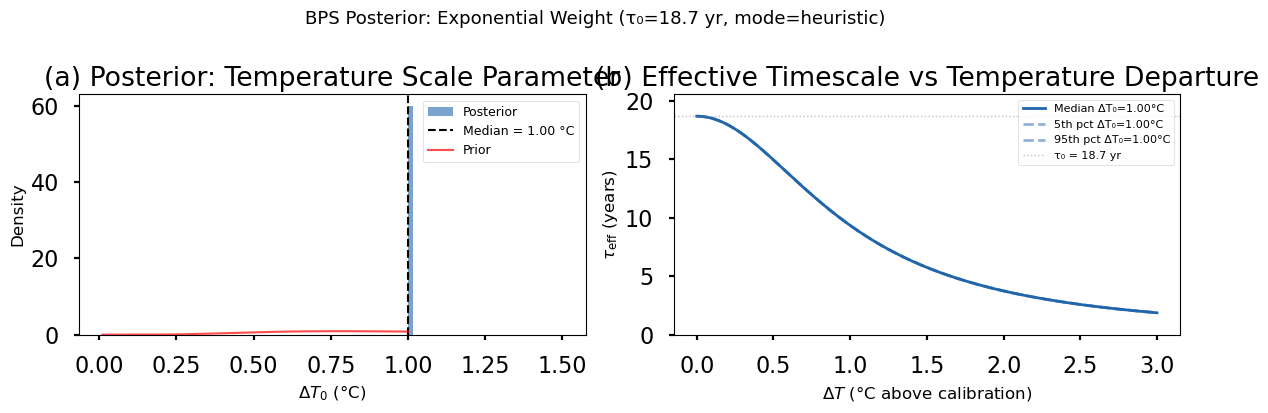

Saved: ../figures/hybrid_fig1_bps_posterior.png

BPS Posterior Summary:
  delta_T0             1.0000      1.0000      1.0000 °C
  tau_0 (fixed)          18.7  yr


In [30]:
# ============================================================
# Cell 10: Figure 1 — BPS posterior
# ============================================================
samples = bps.get_posterior_samples()

if WEIGHT_MODE in ('heuristic', 'cv', 'state'):
    # --- 1D posterior histogram for ΔT₀ ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Panel (a): ΔT₀ posterior
    ax = axes[0]
    dT0_samp = samples[:, 0]
    ax.hist(dT0_samp, bins=60, density=True, color='#2166ac',
            alpha=0.6, edgecolor='none', label='Posterior')
    ax.axvline(np.median(dT0_samp), color='k', ls='--', lw=1.5,
               label=f'Median = {np.median(dT0_samp):.2f} °C')

    # Prior overlay
    x_range = np.linspace(0.01, np.percentile(dT0_samp, 99.5), 200)
    prior_pdf = stats.lognorm.pdf(x_range, s=0.5, scale=1.0)
    ax.plot(x_range, prior_pdf, 'r-', lw=1.5, alpha=0.7, label='Prior')

    ax.set_xlabel(r'$\Delta T_0$ (°C)', fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.set_title('(a) Posterior: Temperature Scale Parameter')
    ax.legend(fontsize=9)

    # Panel (b): Effective timescale vs ΔT
    ax = axes[1]
    dT_range = np.linspace(0, 3.0, 200)
    dT0_med = np.median(dT0_samp)
    dT0_p5 = np.percentile(dT0_samp, 5)
    dT0_p95 = np.percentile(dT0_samp, 95)

    for dT0_val, ls, alpha, lbl in [
        (dT0_med, '-', 1.0, f'Median ΔT₀={dT0_med:.2f}°C'),
        (dT0_p5, '--', 0.5, f'5th pct ΔT₀={dT0_p5:.2f}°C'),
        (dT0_p95, '--', 0.5, f'95th pct ΔT₀={dT0_p95:.2f}°C'),
    ]:
        tau_eff = TAU_0 / (1.0 + (dT_range / dT0_val)**2)
        ax.plot(dT_range, tau_eff, ls=ls, color='#2166ac', alpha=alpha,
                lw=2, label=lbl)

    ax.axhline(TAU_0, color='gray', ls=':', lw=1, alpha=0.5,
               label=f'τ₀ = {TAU_0:.1f} yr')
    ax.set_xlabel(r'$\Delta T$ (°C above calibration)', fontsize=12)
    ax.set_ylabel(r'$\tau_{\mathrm{eff}}$ (years)', fontsize=12)
    ax.set_title('(b) Effective Timescale vs Temperature Departure')
    ax.legend(fontsize=8, loc='upper right')
    ax.set_ylim(0, TAU_0 * 1.1)

    fig.suptitle(f'BPS Posterior: Exponential Weight (τ₀={TAU_0:.1f} yr, mode={WEIGHT_MODE})',
                 fontsize=13, y=1.02)
    plt.tight_layout()

else:
    # --- 3x3 corner plot for sigmoid mode ---
    labels = [r'$\phi_0$', r'$\kappa_{\mathrm{net}}$', r'$\kappa_t$']
    fig, axes = plt.subplots(3, 3, figsize=(8, 8))

    for i in range(3):
        for j in range(3):
            ax = axes[i, j]
            if j > i:
                ax.set_visible(False)
                continue
            if i == j:
                ax.hist(samples[:, i], bins=50, density=True, color='#2166ac',
                        alpha=0.6, edgecolor='none')
                ax.axvline(np.median(samples[:, i]), color='k', ls='--', lw=1)
            else:
                ax.scatter(samples[:, j], samples[:, i], s=0.3, alpha=0.1,
                           color='#2166ac', rasterized=True)
            if i == 2:
                ax.set_xlabel(labels[j], fontsize=11)
            if j == 0:
                ax.set_ylabel(labels[i], fontsize=11)

    fig.suptitle('BPS Posterior: Synthesis Hyperparameters (sigmoid)', fontsize=13, y=0.98)
    plt.tight_layout()

fig_path = os.path.join(FIGURE_DIR, 'hybrid_fig1_bps_posterior.png')
plt.savefig(fig_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path}')

# Print summary statistics
print(f'\nBPS Posterior Summary:')
if WEIGHT_MODE in ('heuristic', 'cv', 'state'):
    med = np.median(samples[:, 0])
    p5 = np.percentile(samples[:, 0], 5)
    p95 = np.percentile(samples[:, 0], 95)
    print(f'  {"delta_T0":<15s}  {med:10.4f}  {p5:10.4f}  {p95:10.4f} °C')
    print(f'  {"tau_0 (fixed)":<15s}  {TAU_0:10.1f}  yr')
else:
    print(f'  {"Parameter":<15s}  {"Median":>10s}  {"5th":>10s}  {"95th":>10s}')
    print(f'  {"-"*50}')
    for i, name in enumerate(['phi_0', 'kappa_net', 'kappa_t']):
        med = np.median(samples[:, i])
        p5 = np.percentile(samples[:, i], 5)
        p95 = np.percentile(samples[:, i], 95)
        print(f'  {name:<15s}  {med:10.4f}  {p5:10.4f}  {p95:10.4f}')

## 6. Per-SSP Projections

For each SSP: compute temperature departure, trend projection ensemble, posterior weights,
mixture quantiles, stochastic-transition trajectories, and WAIS add-back.

In [31]:
# ============================================================
# Cell 11: Per-SSP projections
# ============================================================

# SSP configuration
ssps_to_plot = ['SSP1-2.6', 'SSP2-4.5', 'SSP3-7.0', 'SSP5-8.5']
ssp_colors = {
    'SSP1-2.6': '#4393c3', 'SSP2-4.5': '#2166ac',
    'SSP3-7.0': '#084594', 'SSP5-8.5': '#052d5e',
}
ssp_colors_light = {
    'SSP1-2.6': '#c6dbef', 'SSP2-4.5': '#9ecae1',
    'SSP3-7.0': '#6baed6', 'SSP5-8.5': '#4292c6',
}

# Common projection time grid
t_proj = np.arange(t_end, 2101, 1.0)

# Generate trend agent ensemble (shared across SSPs)
derivatives = sample_derivatives(prediction, n_samples=N_ENSEMBLE, seed=42)
H_trend_ens = trend_projection_ensemble(t_proj, t_end, derivatives)

# Store results for each SSP
bps_results = {}
delta_T_by_ssp = {}

for ssp in ssps_to_plot:
    print(f'\n--- {ssp} ---')

    # Temperature scenario
    temp_df = full_temp_scenarios[ssp]
    T_ssp = np.interp(t_proj, temp_df['decimal_year'].values,
                       temp_df['temperature'].values)

    # Temperature departure
    delta_T = compute_delta_T(T_ssp, T_max_cal, overshoot_mode=True)
    delta_T_by_ssp[ssp] = delta_T
    dt = t_proj - t_end

    # Model agent ensemble (resample to N_ENSEMBLE)
    mc = mc_results[ssp]
    H_model_full = mc['gmsl_samples']
    model_time = mc['time']
    # Interpolate model ensemble to t_proj
    H_model_interp = np.array([
        np.interp(t_proj, model_time, H_model_full[k])
        for k in range(H_model_full.shape[0])
    ])

    # Posterior mean weight
    w_bar = bps.posterior_mean_weight(dt, delta_T)

    # Mixture quantiles
    Q_mixture = compute_mixture_quantiles(H_trend_ens, H_model_interp, w_bar)

    # Align ensemble sizes for stochastic transition
    H_trend_aligned, H_model_aligned = align_ensemble_sizes(
        H_trend_ens, H_model_interp, target_size=N_ENSEMBLE, seed=42,
    )

    # Per-sample weight trajectories
    w_ensemble = bps.posterior_weight_ensemble(dt, delta_T, n_samples=N_ENSEMBLE, seed=42)

    # Stochastic-transition trajectories
    transition = generate_stochastic_transition_ensemble(
        H_trend_aligned, H_model_aligned, w_ensemble, epsilon=0.05, seed=42,
    )

    # Rate smoothness diagnostic
    smoothness = rate_smoothness_diagnostic(transition['H_combined'], t_proj)

    bps_results[ssp] = {
        'delta_T': delta_T,
        'dt': dt,
        'w_bar': w_bar,
        'Q_mixture': Q_mixture,
        'H_trend_aligned': H_trend_aligned,
        'H_model_aligned': H_model_aligned,
        'H_combined': transition['H_combined'],
        'transition_times_idx': transition['transition_times_idx'],
        'smoothness': smoothness,
        'w_ensemble': w_ensemble,
    }

    # Summary
    idx_2050 = np.argmin(np.abs(t_proj - 2050))
    idx_2100 = np.argmin(np.abs(t_proj - 2100))
    print(f'  dT at 2050: {delta_T[idx_2050]:.2f} C, '
          f'dT at 2100: {delta_T[idx_2100]:.2f} C')
    print(f'  w_bar at 2050: {w_bar[idx_2050]:.3f}, '
          f'w_bar at 2100: {w_bar[idx_2100]:.3f}')
    print(f'  BPS median at 2100: '
          f'{Q_mixture["values"][2, idx_2100]*M_TO_MM:.0f} mm')
    print(f'  Rate smoothness: max_jump_frac = {smoothness["max_jump_fraction"]:.3f}')

print('\nAll SSP projections complete.')


--- SSP1-2.6 ---
  dT at 2050: 0.35 C, dT at 2100: 0.43 C
  w_bar at 2050: 0.156, w_bar at 2100: 0.006
  BPS median at 2100: 766 mm
  Rate smoothness: max_jump_frac = 0.041

--- SSP2-4.5 ---
  dT at 2050: 0.56 C, dT at 2100: 1.37 C
  w_bar at 2050: 0.114, w_bar at 2100: 0.000
  BPS median at 2100: 1293 mm
  Rate smoothness: max_jump_frac = 0.128

--- SSP3-7.0 ---
  dT at 2050: 0.71 C, dT at 2100: 2.54 C
  w_bar at 2050: 0.082, w_bar at 2100: 0.000
  BPS median at 2100: 1988 mm
  Rate smoothness: max_jump_frac = 0.244

--- SSP5-8.5 ---
  dT at 2050: 0.94 C, dT at 2100: 3.35 C
  w_bar at 2050: 0.044, w_bar at 2100: 0.000
  BPS median at 2100: 2764 mm
  Rate smoothness: max_jump_frac = 0.264

All SSP projections complete.


## Figure 2: Posterior Weight Timeseries

Plot w-bar(t) vs year for all SSPs. Shaded region shows 5th-95th percentile of w(t; psi)
across posterior samples.

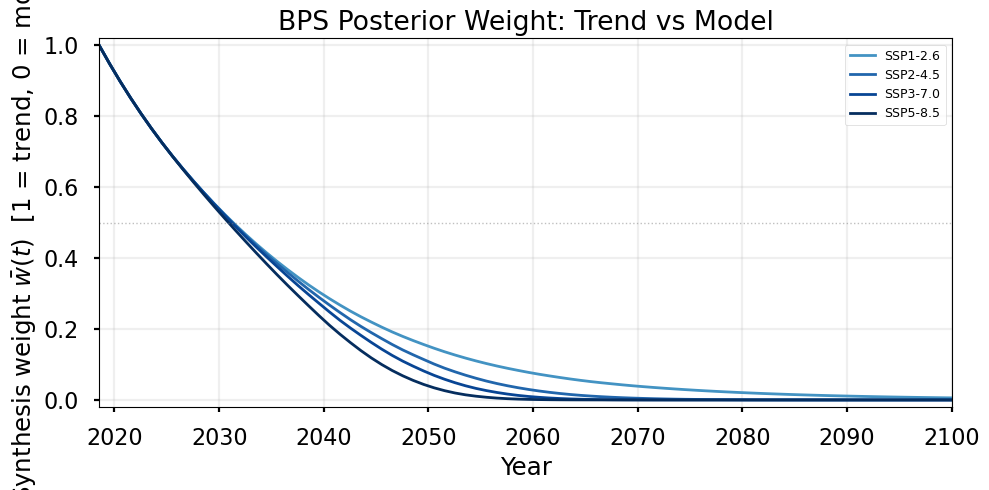

Saved: ../figures/hybrid_fig2_weight_timeseries.png


In [32]:
# ============================================================
# Cell 12: Figure 2 — Posterior weight timeseries
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5))

for ssp in ssps_to_plot:
    r = bps_results[ssp]
    w_ens = r['w_ensemble']  # (N_ENSEMBLE, n_proj)
    w_med = np.median(w_ens, axis=0)
    w_p5 = np.percentile(w_ens, 5, axis=0)
    w_p95 = np.percentile(w_ens, 95, axis=0)

    ax.plot(t_proj, w_med, color=ssp_colors[ssp], lw=2, label=ssp)
    ax.fill_between(t_proj, w_p5, w_p95, color=ssp_colors[ssp], alpha=0.12)

ax.axhline(0.5, color='gray', ls=':', lw=1, alpha=0.5)
ax.set_xlim(t_proj[0], min(2100, t_proj[-1]))
ax.set_ylim(-0.02, 1.02)
ax.set_xlabel('Year')
ax.set_ylabel('Synthesis weight $\\bar{w}(t)$  [1 = trend, 0 = model]')
ax.set_title('BPS Posterior Weight: Trend vs Model')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.2)

plt.tight_layout()
fig_path = os.path.join(FIGURE_DIR, 'hybrid_fig2_weight_timeseries.png')
plt.savefig(fig_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path}')

## Figure 3: Combined Projection Fan Chart

For each SSP, overlay the model-only, trend-only, and BPS mixture predictive 90% CI.
Shows how the BPS combination transitions from trend-dominated to model-dominated.

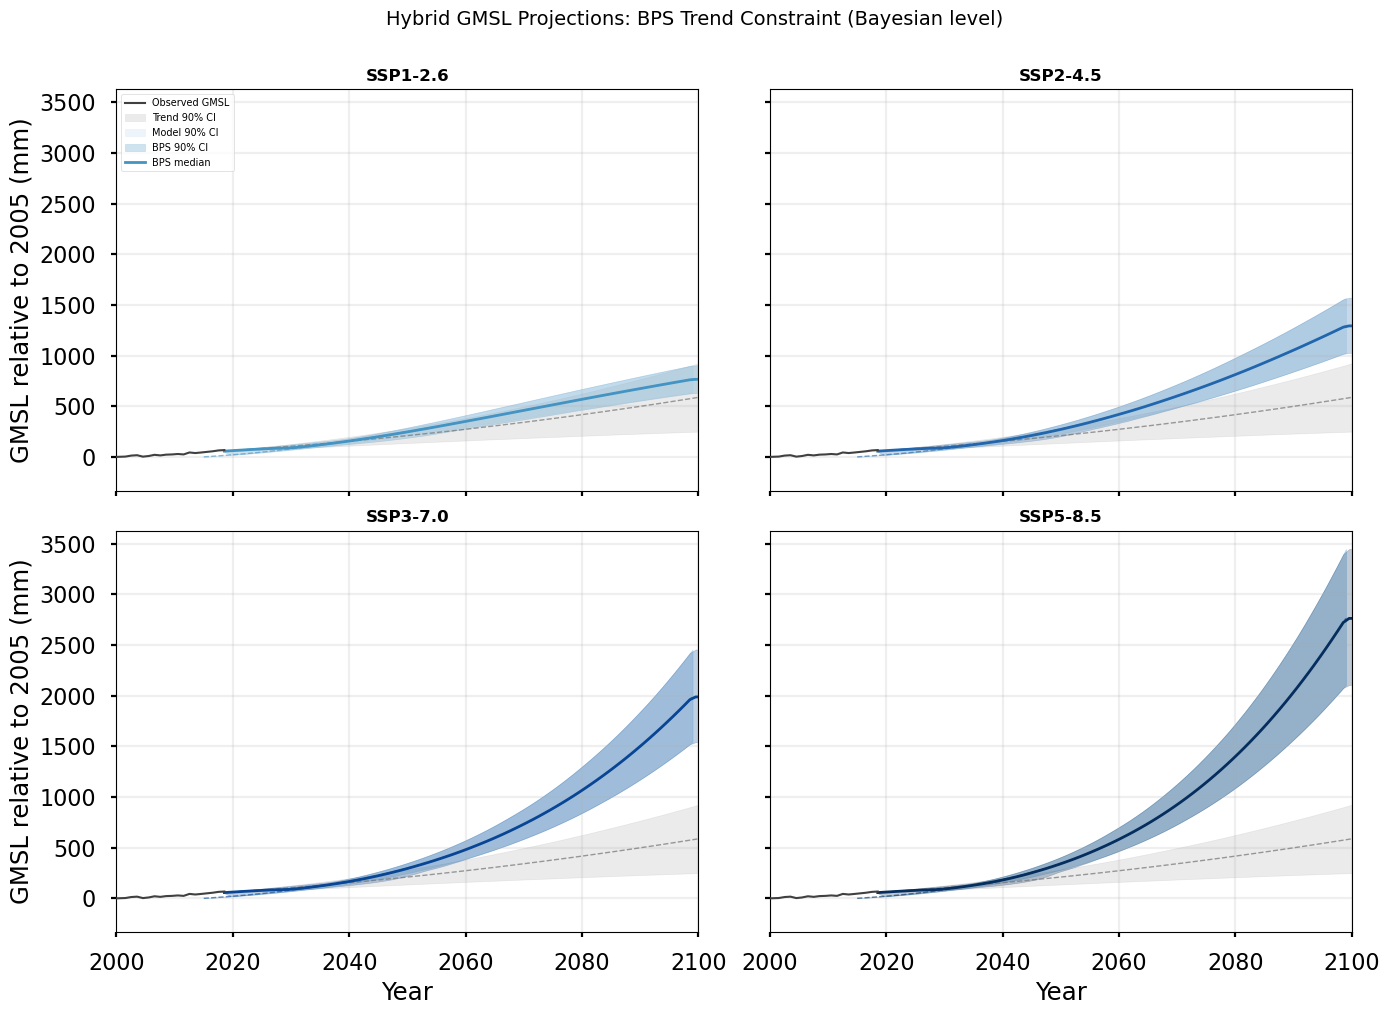

Saved: ../figures/hybrid_fig3_projection_fan.png


In [33]:
# ============================================================
# Cell 13: Figure 3 — Combined projection fan chart
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
axes_flat = axes.flatten()

for ax_idx, ssp in enumerate(ssps_to_plot):
    ax = axes_flat[ax_idx]
    r = bps_results[ssp]
    Q = r['Q_mixture']

    # Observed
    ax.plot(obs_years, H_obs_full * M_TO_MM, '-', color='#404040', lw=1.5,
            label='Observed GMSL', zorder=5)

    # Trend-only 90% CI
    H_trend_p5 = np.percentile(H_trend_ens, 5, axis=0)
    H_trend_p95 = np.percentile(H_trend_ens, 95, axis=0)
    H_trend_med = np.median(H_trend_ens, axis=0)
    ax.fill_between(t_proj, H_trend_p5 * M_TO_MM, H_trend_p95 * M_TO_MM,
                     color='#bdbdbd', alpha=0.3, label='Trend 90% CI')
    ax.plot(t_proj, H_trend_med * M_TO_MM, '--', color='#737373', lw=1, alpha=0.7)

    # Model-only 90% CI
    mc = mc_results[ssp]
    model_time = mc['time']
    ax.fill_between(model_time, mc['gmsl_p5'] * M_TO_MM, mc['gmsl_p95'] * M_TO_MM,
                     color=ssp_colors_light[ssp], alpha=0.3, label='Model 90% CI')
    ax.plot(model_time, mc['gmsl_median'] * M_TO_MM, '--',
            color=ssp_colors[ssp], lw=1, alpha=0.6)

    # BPS mixture 90% CI (primary)
    q_vals = Q['values']
    ax.fill_between(t_proj, q_vals[0] * M_TO_MM, q_vals[4] * M_TO_MM,
                     color=ssp_colors[ssp], alpha=0.25, label='BPS 90% CI')
    ax.plot(t_proj, q_vals[2] * M_TO_MM, '-', color=ssp_colors[ssp], lw=2,
            label='BPS median')

    ax.set_title(ssp, fontsize=12, fontweight='bold')
    ax.set_xlim(2000, 2100)
    ax.grid(True, alpha=0.2)
    if ax_idx >= 2:
        ax.set_xlabel('Year')
    if ax_idx % 2 == 0:
        ax.set_ylabel('GMSL relative to 2005 (mm)')
    if ax_idx == 0:
        ax.legend(loc='upper left', fontsize=7, ncol=1)

model_label = 'Bayesian level' if MODEL_CHOICE == 'level' else 'Bayesian rate-and-state'
fig.suptitle(f'Hybrid GMSL Projections: BPS Trend Constraint ({model_label})',
             fontsize=14, y=1.01)
plt.tight_layout()
fig_path = os.path.join(FIGURE_DIR, 'hybrid_fig3_projection_fan.png')
plt.savefig(fig_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path}')

## Figure 4: CV Log Predictive Scores

For each holdout endpoint, plot the log predictive score of the trend agent, model agent,
and BPS combined as a function of lead time.

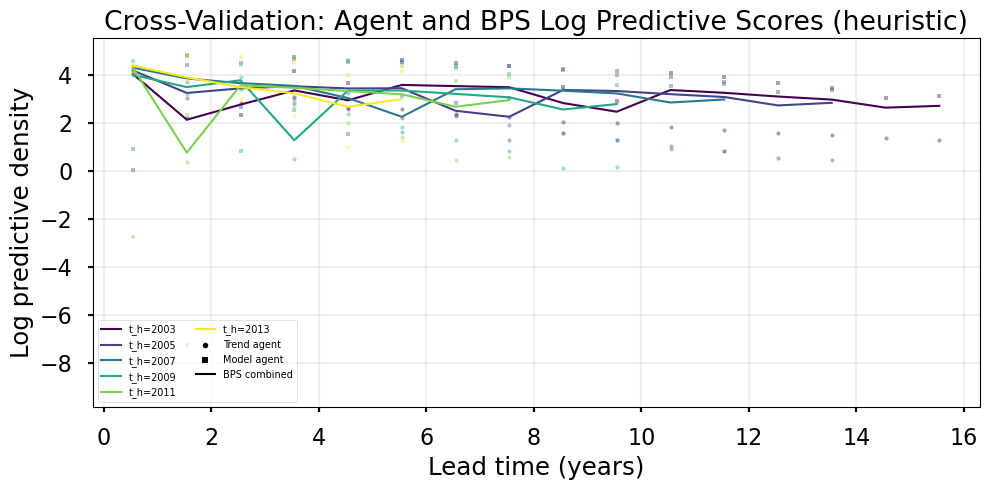

Saved: ../figures/hybrid_fig4_cv_scores.png


In [34]:
# ============================================================
# Cell 14: Figure 4 — CV log predictive scores
# ============================================================
from scipy.special import expit as _expit

# Use posterior median for weight computation
psi_med = np.median(bps.get_posterior_samples(), axis=0)

fig, ax = plt.subplots(figsize=(10, 5))
cmap = plt.cm.viridis

for j, fold in enumerate(cv_data):
    dt_cv = fold['dt']
    dT_cv = fold['delta_T']
    log_ht = fold['log_h_trend']
    log_hm = fold['log_h_model']

    if WEIGHT_MODE in ('heuristic', 'cv', 'state'):
        # Exponential weight at posterior median ΔT₀
        dT0_med = psi_med[0]
        tau_eff = TAU_0 / (1.0 + (dT_cv / dT0_med)**2)
        tau_eff = np.maximum(tau_eff, 1e-10)
        w_cv = np.exp(-dt_cv / tau_eff)
        w_cv = np.clip(w_cv, 1e-15, 1.0 - 1e-15)
        log_w = np.log(w_cv)
        log_1mw = np.log(1.0 - w_cv)
    else:
        # Sigmoid weight at posterior median
        phi0_med, kn_med, kt_med = psi_med
        phi_cv = phi0_med - kn_med * dT_cv**2 * dt_cv**2 - kt_med * dt_cv**4
        log_w = -np.logaddexp(0.0, -phi_cv)
        log_1mw = -np.logaddexp(0.0, phi_cv)

    # BPS combined log-density
    log_bps = np.logaddexp(log_w + log_ht, log_1mw + log_hm)

    color = cmap(j / max(len(cv_data) - 1, 1))
    lbl = f't_h={fold["t_h"]:.0f}'
    ax.plot(dt_cv, log_ht, 'o', color=color, ms=3, alpha=0.4)
    ax.plot(dt_cv, log_hm, 's', color=color, ms=3, alpha=0.4)
    ax.plot(dt_cv, log_bps, '-', color=color, lw=1.5, label=lbl)

# Legend entries for markers
ax.plot([], [], 'ok', ms=4, label='Trend agent')
ax.plot([], [], 'sk', ms=4, label='Model agent')
ax.plot([], [], '-k', lw=1.5, label='BPS combined')

ax.set_xlabel('Lead time (years)')
ax.set_ylabel('Log predictive density')
ax.set_title(f'Cross-Validation: Agent and BPS Log Predictive Scores ({WEIGHT_MODE})')
ax.legend(loc='lower left', fontsize=7, ncol=2)
ax.grid(True, alpha=0.2)

plt.tight_layout()
fig_path = os.path.join(FIGURE_DIR, 'hybrid_fig4_cv_scores.png')
plt.savefig(fig_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path}')

## Figure 5: Transition Time Distribution

Histogram of transition times across the stochastic-transition trajectory ensemble,
showing when individual trajectories switch from trend-dominated to model-dominated.

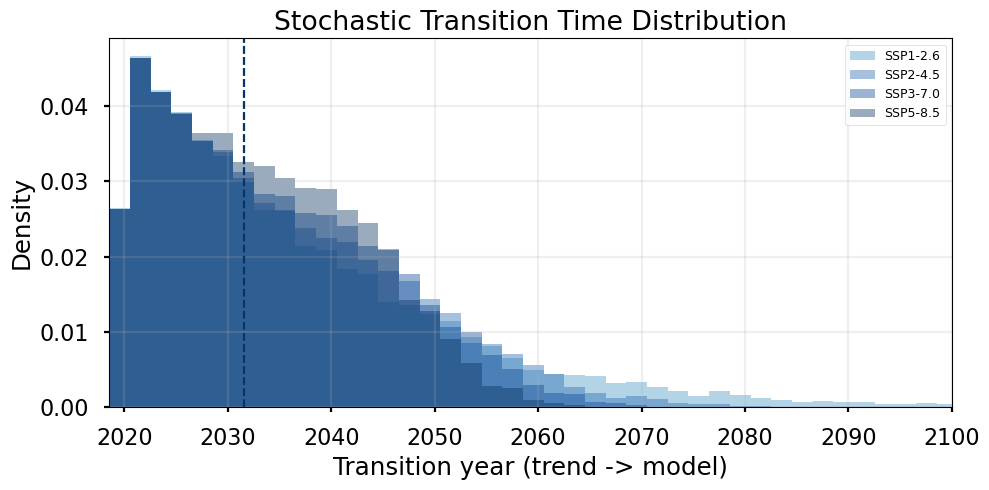

Saved: ../figures/hybrid_fig5_transition_times.png


In [35]:
# ============================================================
# Cell 15: Figure 5 — Transition time distribution
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5))
bins = np.arange(t_end, 2105, 2)

for ssp in ssps_to_plot:
    r = bps_results[ssp]
    trans_idx = r['transition_times_idx']
    # Convert index to year
    trans_years = t_proj[np.clip(trans_idx, 0, len(t_proj) - 1)]
    # Filter out samples that never transition (index at end)
    valid = trans_idx < len(t_proj) - 1
    if valid.sum() > 0:
        ax.hist(trans_years[valid], bins=bins, density=True,
                alpha=0.4, color=ssp_colors[ssp], label=ssp, edgecolor='none')
        # Median line
        med_yr = np.median(trans_years[valid])
        ax.axvline(med_yr, color=ssp_colors[ssp], ls='--', lw=1.5, alpha=0.8)

ax.set_xlabel('Transition year (trend -> model)')
ax.set_ylabel('Density')
ax.set_title('Stochastic Transition Time Distribution')
ax.set_xlim(t_end, 2100)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.2)

plt.tight_layout()
fig_path = os.path.join(FIGURE_DIR, 'hybrid_fig5_transition_times.png')
plt.savefig(fig_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path}')

## Figure 6: Rate Smoothness

For one SSP, overlay 50 combined trajectories and their rates (finite differences).
Verify smooth transitions.

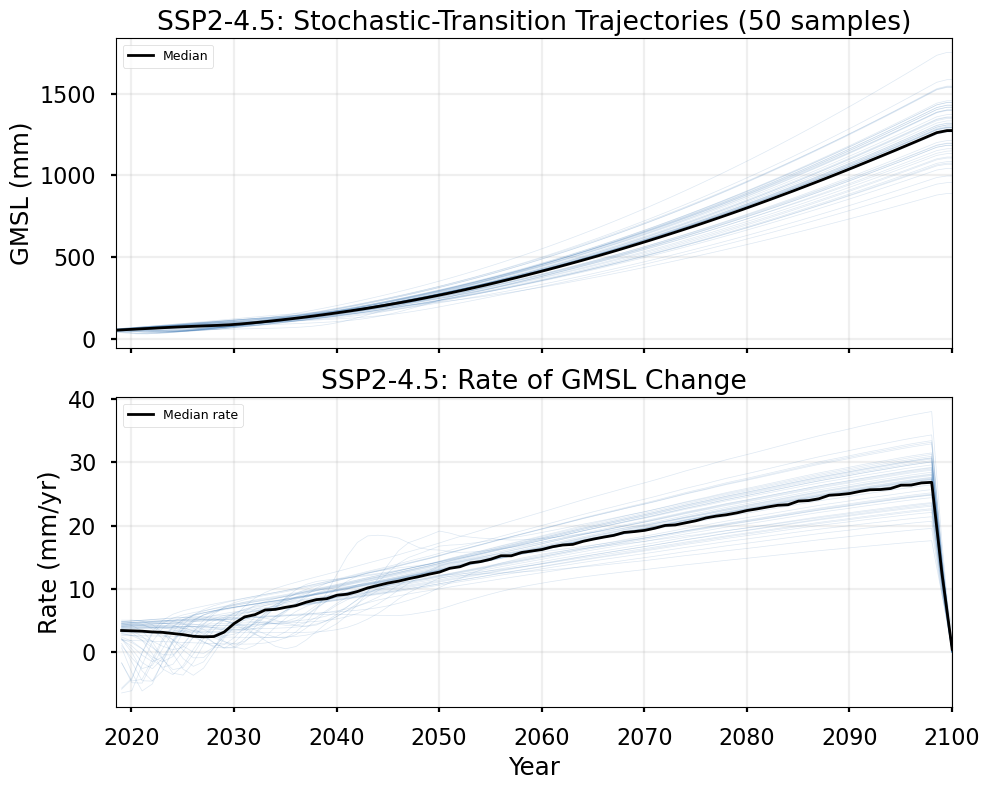

Saved: ../figures/hybrid_fig6_rate_smoothness.png
Rate smoothness diagnostic: max_jump_fraction = 0.1284


In [36]:
# ============================================================
# Cell 16: Figure 6 — Rate smoothness (SSP2-4.5)
# ============================================================
ssp_show = 'SSP2-4.5'
r = bps_results[ssp_show]
H_comb = r['H_combined']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

n_show = 50
rng_show = np.random.default_rng(0)
idx_show = rng_show.choice(H_comb.shape[0], n_show, replace=False)

# Trajectories
for k in idx_show:
    ax1.plot(t_proj, H_comb[k] * M_TO_MM, color=ssp_colors[ssp_show],
             alpha=0.15, lw=0.5)
# Median
ax1.plot(t_proj, np.median(H_comb, axis=0) * M_TO_MM, 'k-', lw=2, label='Median')
ax1.set_ylabel('GMSL (mm)')
ax1.set_title(f'{ssp_show}: Stochastic-Transition Trajectories ({n_show} samples)')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.2)

# Rates (finite differences)
dt_proj = np.diff(t_proj)
t_rate = 0.5 * (t_proj[:-1] + t_proj[1:])
for k in idx_show:
    rate_k = np.diff(H_comb[k]) / dt_proj * M_TO_MM
    ax2.plot(t_rate, rate_k, color=ssp_colors[ssp_show], alpha=0.15, lw=0.5)
# Median rate
med_rate = np.diff(np.median(H_comb, axis=0)) / dt_proj * M_TO_MM
ax2.plot(t_rate, med_rate, 'k-', lw=2, label='Median rate')
ax2.set_ylabel('Rate (mm/yr)')
ax2.set_xlabel('Year')
ax2.set_title(f'{ssp_show}: Rate of GMSL Change')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.2)
ax2.set_xlim(t_proj[0], min(2100, t_proj[-1]))

plt.tight_layout()
fig_path = os.path.join(FIGURE_DIR, 'hybrid_fig6_rate_smoothness.png')
plt.savefig(fig_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path}')
print(f'Rate smoothness diagnostic: max_jump_fraction = '
      f'{r["smoothness"]["max_jump_fraction"]:.4f}')

## 7. Crossover Diagnostics and Summary Tables

Compute the crossover time posterior for each SSP and summarize all results.

In [37]:
# ============================================================
# Cell 17: Crossover diagnostics
# ============================================================

# Temperature rates for analytic approximation
# (None for overshoot SSPs)
T_rate_by_ssp = {}
for ssp in ssps_to_plot:
    temp_df = full_temp_scenarios[ssp]
    T_vals = temp_df['temperature'].values
    t_vals = temp_df['decimal_year'].values
    # Approximate dT/dt near start of projection
    mask_near = (t_vals >= t_end) & (t_vals <= t_end + 20)
    if mask_near.sum() > 2:
        T_rate_by_ssp[ssp] = float(np.polyfit(t_vals[mask_near], T_vals[mask_near], 1)[0])
    else:
        T_rate_by_ssp[ssp] = None

# Skip analytic for overshoot SSPs
for ssp in ['SSP1-1.9', 'SSP1-2.6']:
    if ssp in T_rate_by_ssp:
        T_rate_by_ssp[ssp] = None

crossover = compute_crossover_diagnostics(
    bps, t_proj, t_end, delta_T_by_ssp, T_rate_by_ssp,
)

# Print crossover table
print(f'{"SSP":<12s} {"t* med":>8s} {"t* 5%":>8s} {"t* 95%":>8s} '
      f'{"w(2050)":>8s} {"w(2100)":>8s} {"Driver":<18s} {"No x-over":>9s}')
print('-' * 95)
for ssp in ssps_to_plot:
    c = crossover[ssp]
    print(f'{ssp:<12s} {c["crossover_median"]:8.1f} {c["crossover_5"]:8.1f} '
          f'{c["crossover_95"]:8.1f} {c["w_bar_at_2050"]:8.3f} '
          f'{c["w_bar_at_2100"]:8.3f} {c["driver"]:<18s} '
          f'{c["fraction_no_crossover"]:9.1%}')

SSP            t* med    t* 5%   t* 95%  w(2050)  w(2100) Driver             No x-over
-----------------------------------------------------------------------------------------------
SSP1-2.6       2031.3   2031.3   2031.3    0.151    0.006 forcing_departure       0.0%
SSP2-4.5       2031.3   2031.3   2031.3    0.108    0.000 forcing_departure       0.0%
SSP3-7.0       2031.2   2031.2   2031.2    0.076    0.000 forcing_departure       0.0%
SSP5-8.5       2030.9   2030.9   2030.9    0.039    0.000 forcing_departure       0.0%


## Figure 7: Crossover Diagnostic — All SSPs on One Panel

Overlay projection comparison for all SSPs: observed data, BPS median, and model median.
Annotate the crossover region for each SSP.

Loaded rate-and-state projections from ../data/processed/bayesian_ratestate_projections.npz


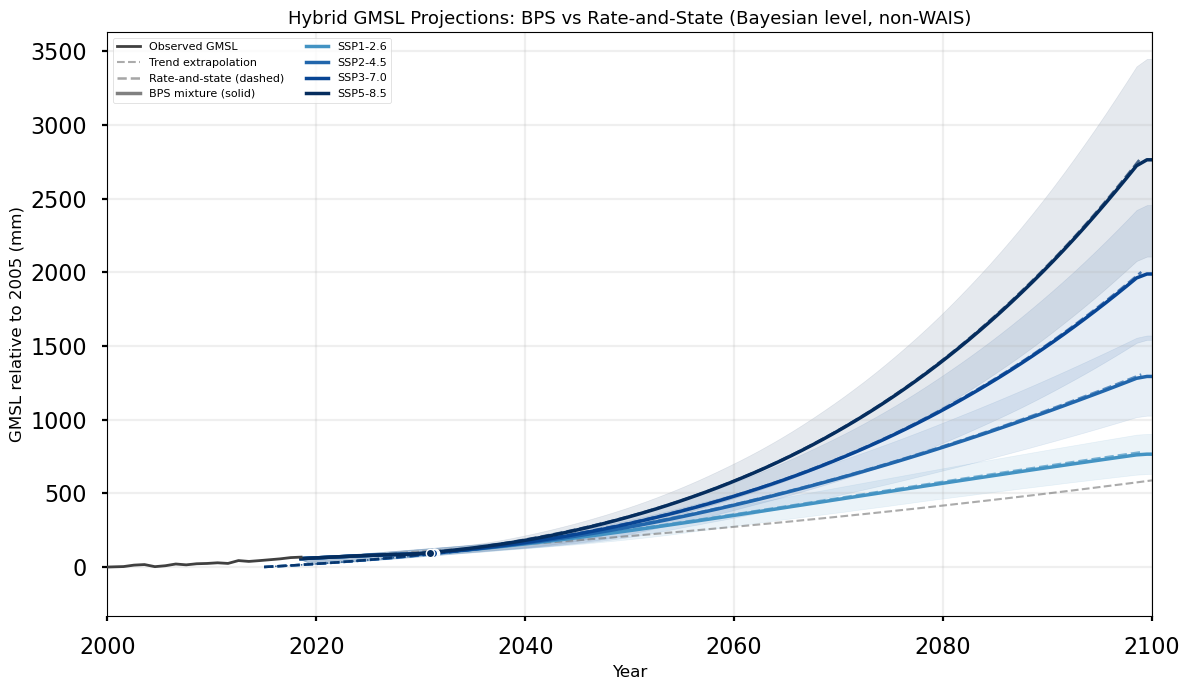

Saved: ../figures/hybrid_fig7_all_ssp_comparison.png


In [38]:
# ============================================================
# Cell 18: Figure 7 — All-SSP projection comparison
# ============================================================

# --- Load Bayesian rate-and-state projections (from bayesian_ratestate.ipynb) ---
ratestate_npz_path = os.path.join(CACHE_DIR,
                                   'bayesian_ratestate_projections.npz')
ratestate_proj = {}
if os.path.exists(ratestate_npz_path):
    _rs = np.load(ratestate_npz_path)
    for ssp in ssps_to_plot:
        ssp_key = ssp.replace('-', '_').replace('.', '_')
        ratestate_proj[ssp] = {
            'time': _rs[f'{ssp_key}_time'],
            'gmsl_median': _rs[f'{ssp_key}_gmsl_median'],   # meters
            'gmsl_lower': _rs[f'{ssp_key}_gmsl_lower'],
            'gmsl_upper': _rs[f'{ssp_key}_gmsl_upper'],
        }
    print(f'Loaded rate-and-state projections from {ratestate_npz_path}')
else:
    print(f'WARNING: {ratestate_npz_path} not found — '
          'run bayesian_ratestate.ipynb first to generate it')

# --- Figure ---
fig, ax = plt.subplots(figsize=(12, 7))

# Observed
ax.plot(obs_years, H_obs_full * M_TO_MM, '-', color='#404040', lw=2,
        label='Observed GMSL', zorder=5)

# Trend extrapolation (shared)
H_trend_med = np.median(H_trend_ens, axis=0)
ax.plot(t_proj, H_trend_med * M_TO_MM, '--', color='#737373', lw=1.5,
        label='Trend extrapolation', alpha=0.6)

for ssp in ssps_to_plot:
    r = bps_results[ssp]
    Q = r['Q_mixture']
    mc = mc_results[ssp]
    color = ssp_colors[ssp]

    # Model-only median (dotted, thin)
    ax.plot(mc['time'], mc['gmsl_median'] * M_TO_MM, ':',
            color=color, lw=1, alpha=0.4)

    # Bayesian rate-and-state median (dashed, same color)
    if ssp in ratestate_proj:
        rs = ratestate_proj[ssp]
        ax.plot(rs['time'], rs['gmsl_median'] * M_TO_MM, '--',
                color=color, lw=1.8, alpha=0.7,
                label=f'{ssp} (rate\u2011&\u2011state)' if ssp == ssps_to_plot[0] else '')
        # Add label only once in legend; use invisible proxy for rest
        if ssp != ssps_to_plot[0]:
            ax.plot([], [], '--', color=color, lw=1.8, alpha=0.7)

    # BPS median (solid) with 90% CI
    ax.plot(t_proj, Q['values'][2] * M_TO_MM, '-',
            color=color, lw=2.5, label=f'{ssp} (BPS)')
    ax.fill_between(t_proj, Q['values'][0] * M_TO_MM, Q['values'][4] * M_TO_MM,
                     color=color, alpha=0.10)

    # Annotate crossover median
    c = crossover[ssp]
    if np.isfinite(c['crossover_median']):
        yr_cross = c['crossover_median']
        idx_cross = np.argmin(np.abs(t_proj - yr_cross))
        y_cross = Q['values'][2, idx_cross] * M_TO_MM
        ax.plot(yr_cross, y_cross, 'o', color=color, ms=6,
                markeredgecolor='white', markeredgewidth=1, zorder=6)

# Custom legend: group by line style
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='#404040', lw=2, label='Observed GMSL'),
    Line2D([0], [0], color='#737373', ls='--', lw=1.5, alpha=0.6,
           label='Trend extrapolation'),
]
if ratestate_proj:
    legend_elements.append(
        Line2D([0], [0], color='gray', ls='--', lw=1.8, alpha=0.7,
               label='Rate-and-state (dashed)'))
legend_elements.append(
    Line2D([0], [0], color='gray', ls='-', lw=2.5,
           label='BPS mixture (solid)'))
for ssp in ssps_to_plot:
    legend_elements.append(
        Line2D([0], [0], color=ssp_colors[ssp], ls='-', lw=2.5, label=ssp))

ax.legend(handles=legend_elements, loc='upper left', fontsize=8, ncol=2)

ax.set_xlim(2000, 2100)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('GMSL relative to 2005 (mm)', fontsize=12)
model_label = 'Bayesian level' if MODEL_CHOICE == 'level' else 'Bayesian rate-and-state'
ax.set_title(f'Hybrid GMSL Projections: BPS vs Rate-and-State ({model_label}, non-WAIS)',
             fontsize=13)
ax.grid(True, alpha=0.2)

plt.tight_layout()
fig_path = os.path.join(FIGURE_DIR, 'hybrid_fig7_all_ssp_comparison.png')
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path}')

## Summary

Projection summary at key years and holdout influence diagnostics.

In [39]:
# ============================================================
# Cell 19: Summary tables
# ============================================================

model_label = 'Bayesian level (3-param)' if MODEL_CHOICE == 'level' \
    else 'Bayesian rate-and-state (4-param + τ)'
print(f'Model agent:  {model_label}')
print(f'Weight mode:  {WEIGHT_MODE}')
print(f'CV cache:     {CV_CACHE_PATH}')
print()

# Weight function summary
if WEIGHT_MODE in ('heuristic', 'cv', 'state'):
    dT0_post = bps.get_posterior_samples()[:, 0]
    print(f'Exponential weight: w(dt) = exp(-dt / τ_eff)')
    print(f'  τ_eff(ΔT) = τ₀ / (1 + (ΔT/ΔT₀)²)')
    print(f'  τ₀ = {TAU_0:.1f} yr (from rate-and-state calibration)')
    print(f'  ΔT₀: median = {np.median(dT0_post):.3f} °C, '
          f'90% CI = [{np.percentile(dT0_post, 5):.3f}, {np.percentile(dT0_post, 95):.3f}] °C')
    print()

# Projection summary at key years
eval_years = [2030, 2050, 2075, 2100]
print('BPS Mixture Median GMSL (mm, relative to 2005, non-WAIS):')
print(f'  {"SSP":<12s}', '  '.join(f'{yr:>8d}' for yr in eval_years))
print('  ' + '-' * (12 + 10 * len(eval_years)))
for ssp in ssps_to_plot:
    Q = bps_results[ssp]['Q_mixture']
    vals = []
    for yr in eval_years:
        idx = np.argmin(np.abs(t_proj - yr))
        vals.append(f'{Q["values"][2, idx] * M_TO_MM:8.0f}')
    print(f'  {ssp:<12s}', '  '.join(vals))

print()
print('BPS 90% CI width (mm):')
print(f'  {"SSP":<12s}', '  '.join(f'{yr:>8d}' for yr in eval_years))
print('  ' + '-' * (12 + 10 * len(eval_years)))
for ssp in ssps_to_plot:
    Q = bps_results[ssp]['Q_mixture']
    vals = []
    for yr in eval_years:
        idx = np.argmin(np.abs(t_proj - yr))
        width = (Q['values'][4, idx] - Q['values'][0, idx]) * M_TO_MM
        vals.append(f'{width:8.0f}')
    print(f'  {ssp:<12s}', '  '.join(vals))

# Holdout influence diagnostics
print('\nHoldout influence diagnostics:')
influence = bps.holdout_influence_diagnostics(cv_data)
for t_h, ess in sorted(influence['ess_per_fold'].items()):
    flag = ' <-- FLAGGED' if t_h in influence['flagged_for_refit'] else ''
    print(f'  t_h={t_h:.0f}: ESS = {ess:.0f}{flag}')

# Convergence summary
if WEIGHT_MODE != 'heuristic':
    print('\nConvergence diagnostics:')
    conv = bps.convergence_diagnostics()
    print(f'  Converged: {conv["converged"]}')
    print(f'  Acceptance fraction: {conv.get("acceptance_fraction", "N/A")}')
    for var, rh in conv['rhat'].items():
        print(f'  {var}: R-hat={rh:.3f}, ESS_bulk={conv["ess_bulk"][var]:.0f}, '
              f'ESS_tail={conv["ess_tail"][var]:.0f}')

# Bayesian calibration summary
print(f'\nBayesian calibration posterior summary (mm units):')
if MODEL_CHOICE == 'level':
    names = ['a (da/dT)', 'b (alpha_0)', 'c (trend)']
    for i, nm in enumerate(names):
        samp = bayes_result.posterior_samples[:, i] * M_TO_MM
        print(f'  {nm:<15s}: median={np.median(samp):.3f}, '
              f'90% CI=[{np.percentile(samp, 5):.3f}, {np.percentile(samp, 95):.3f}]')
elif MODEL_CHOICE == 'state':
    names = ['a (da/dT)', 'b (alpha_0)', 'c (trend)', 'd (diseq)']
    for i, nm in enumerate(names):
        samp = bayes_result.posterior_samples[:, i] * M_TO_MM
        print(f'  {nm:<15s}: median={np.median(samp):.3f}, '
              f'90% CI=[{np.percentile(samp, 5):.3f}, {np.percentile(samp, 95):.3f}]')
    tau = bayes_result.tau_posterior
    print(f'  {"tau (yr)":<15s}: median={np.median(tau):.1f}, '
          f'90% CI=[{np.percentile(tau, 5):.1f}, {np.percentile(tau, 95):.1f}]')

Model agent:  Bayesian level (3-param)
Weight mode:  heuristic
CV cache:     ../data/processed/bps_cv_cache_level_342be754fbb9.npz

Exponential weight: w(dt) = exp(-dt / τ_eff)
  τ_eff(ΔT) = τ₀ / (1 + (ΔT/ΔT₀)²)
  τ₀ = 18.7 yr (from rate-and-state calibration)
  ΔT₀: median = 1.000 °C, 90% CI = [1.000, 1.000] °C

BPS Mixture Median GMSL (mm, relative to 2005, non-WAIS):
  SSP              2030      2050      2075      2100
  ----------------------------------------------------
  SSP1-2.6           88       242       509       766
  SSP2-4.5           88       265       693      1293
  SSP3-7.0           88       287       872      1988
  SSP5-8.5           90       333      1123      2764

BPS 90% CI width (mm):
  SSP              2030      2050      2075      2100
  ----------------------------------------------------
  SSP1-2.6           51        99       187       273
  SSP2-4.5           51       114       271       544
  SSP3-7.0           51       125       364       915
  SSP5-